## Import Libraries

In [175]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.linear_model import LinearRegression

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

pd.set_option(
    "display.max_columns",
    None
)

pd.set_option(
    "display.max_rows",
    100
)

sns.set_theme(
    style="whitegrid"
)

## Load Excel file

In [176]:
file_path = "EduPro Online Platform.xlsx"

teachers = pd.read_excel(
    file_path,
    sheet_name="Teachers"
)

courses = pd.read_excel(
    file_path,
    sheet_name="Courses"
)

transactions = pd.read_excel(
    file_path,
    sheet_name="Transactions"
)

## Display datasets

In [177]:
print("Teachers Dataset")
display(teachers.head())

print("\nCourses Dataset")
display(courses.head())

print("\nTransactions Dataset")
display(transactions.head())

Teachers Dataset


,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14
2,TC00003,Amber Torres,32,Male,Design,4,1.56
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39
4,TC00005,David Williams,34,Male,Finance,2,3.11



Courses Dataset


,CourseID,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,CR00001,Python Basics,Programming,Paid,Beginner,472.28,11.00,4.74
1,CR00002,Java Programming,Programming,Free,Intermediate,0.00,37.70,2.43
2,CR00003,C++ for Beginners,Programming,Free,Beginner,0.00,19.53,3.85
3,CR00004,Advanced Python,Programming,Free,Beginner,0.00,45.13,2.88
4,CR00005,Full Stack Development,Programming,Free,Beginner,0.00,28.68,1.28



Transactions Dataset


,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042


In [178]:
## Dataset dimensions

In [179]:
print(
    "Teachers Shape:",
    teachers.shape
)

print(
    "Courses Shape:",
    courses.shape
)

print(
    "Transactions Shape:",
    transactions.shape
)

Teachers Shape: (60, 7)
Courses Shape: (60, 8)
Transactions Shape: (10000, 7)


## Column names

In [180]:
print("Teachers Columns:")
print(teachers.columns.tolist())

print("\nCourses Columns:")
print(courses.columns.tolist())

print("\nTransactions Columns:")
print(transactions.columns.tolist())

Teachers Columns:
['TeacherID', 'TeacherName', 'Age', 'Gender', 'Expertise', 'YearsOfExperience', 'TeacherRating']

Courses Columns:
['CourseID', 'CourseName', 'CourseCategory', 'CourseType', 'CourseLevel', 'CoursePrice', 'CourseDuration', 'CourseRating']

Transactions Columns:
['TransactionID', 'UserID', 'CourseID', 'TransactionDate', 'Amount', 'PaymentMethod', 'TeacherID']


In [181]:
teachers.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   TeacherID          60 non-null     str    
 1   TeacherName        60 non-null     str    
 2   Age                60 non-null     int64  
 3   Gender             60 non-null     str    
 4   Expertise          60 non-null     str    
 5   YearsOfExperience  60 non-null     int64  
 6   TeacherRating      60 non-null     float64
dtypes: float64(1), int64(2), str(4)
memory usage: 3.4 KB


In [182]:
courses.info()

<class 'pandas.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   CourseID        60 non-null     str    
 1   CourseName      60 non-null     str    
 2   CourseCategory  60 non-null     str    
 3   CourseType      60 non-null     str    
 4   CourseLevel     60 non-null     str    
 5   CoursePrice     60 non-null     float64
 6   CourseDuration  60 non-null     float64
 7   CourseRating    60 non-null     float64
dtypes: float64(3), str(5)
memory usage: 3.9 KB


In [183]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  str           
 1   UserID           10000 non-null  str           
 2   CourseID         10000 non-null  str           
 3   TransactionDate  10000 non-null  datetime64[us]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  str           
 6   TeacherID        10000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 547.0 KB


In [184]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   TransactionID    10000 non-null  str           
 1   UserID           10000 non-null  str           
 2   CourseID         10000 non-null  str           
 3   TransactionDate  10000 non-null  datetime64[us]
 4   Amount           10000 non-null  float64       
 5   PaymentMethod    10000 non-null  str           
 6   TeacherID        10000 non-null  str           
dtypes: datetime64[us](1), float64(1), str(5)
memory usage: 547.0 KB


In [185]:
courses.describe()

,CoursePrice,CourseDuration,CourseRating
count,60.000000,60.000000,60.000000
mean,92.986333,27.632500,3.097833
std,153.601506,16.092578,1.171232
min,0.000000,1.200000,1.130000
25%,0.000000,14.500000,2.107500
50%,0.000000,28.505000,3.065000
75%,133.615000,43.012500,4.102500
max,490.900000,49.730000,4.940000


In [186]:
transactions.describe()

,TransactionDate,Amount
count,10000,10000.000000
mean,2025-07-01 03:50:32.640000,91.132347
min,2025-01-01 00:00:00,0.000000
25%,2025-04-02 00:00:00,0.000000
50%,2025-06-30 00:00:00,0.000000
75%,2025-09-28 00:00:00,119.040000
max,2025-12-30 00:00:00,490.900000
std,NaN,152.063524


## Check missing values

In [187]:
print("Teachers Missing Values")
display(
    teachers.isnull().sum()
)

print("Courses Missing Values")
display(
    courses.isnull().sum()
)

print("Transactions Missing Values")
display(
    transactions.isnull().sum()
)

Teachers Missing Values


TeacherID            0
TeacherName          0
Age                  0
Gender               0
Expertise            0
YearsOfExperience    0
TeacherRating        0
dtype: int64

Courses Missing Values


CourseID          0
CourseName        0
CourseCategory    0
CourseType        0
CourseLevel       0
CoursePrice       0
CourseDuration    0
CourseRating      0
dtype: int64

Transactions Missing Values


TransactionID      0
UserID             0
CourseID           0
TransactionDate    0
Amount             0
PaymentMethod      0
TeacherID          0
dtype: int64

## Check duplicate records

In [188]:
print(
    "Teacher duplicates:",
    teachers.duplicated().sum()
)

print(
    "Course duplicates:",
    courses.duplicated().sum()
)

print(
    "Transaction duplicates:",
    transactions.duplicated().sum()
)

Teacher duplicates: 0
Course duplicates: 0
Transaction duplicates: 0


## Clean column names

In [189]:
teachers.columns = (
    teachers.columns
    .str.strip()
)

courses.columns = (
    courses.columns
    .str.strip()
)

transactions.columns = (
    transactions.columns
    .str.strip()
)

## Clean text values

In [190]:
for df in [
    teachers,
    courses,
    transactions
]:

    text_columns = df.select_dtypes(
        include="object"
    ).columns

    for col in text_columns:

        df[col] = (
            df[col]
            .astype(str)
            .str.strip()
        )

## Convert numeric columns

In [191]:
teachers["Age"] = pd.to_numeric(
    teachers["Age"],
    errors="coerce"
)

teachers["YearsOfExperience"] = pd.to_numeric(
    teachers["YearsOfExperience"],
    errors="coerce"
)

teachers["TeacherRating"] = pd.to_numeric(
    teachers["TeacherRating"],
    errors="coerce"
)

courses["CourseRating"] = pd.to_numeric(
    courses["CourseRating"],
    errors="coerce"
)

## Check rating ranges

In [192]:
print(
    "Teacher Rating Range:",
    teachers["TeacherRating"].min(),
    "to",
    teachers["TeacherRating"].max()
)

print(
    "Course Rating Range:",
    courses["CourseRating"].min(),
    "to",
    courses["CourseRating"].max()
)

Teacher Rating Range: 1.05 to 4.97
Course Rating Range: 1.13 to 4.94


## Validate Teacher IDs

In [193]:
invalid_teacher_ids = transactions[
    ~transactions["TeacherID"].isin(
        teachers["TeacherID"]
    )
]

print(
    "Invalid Teacher IDs:",
    len(invalid_teacher_ids)
)

Invalid Teacher IDs: 0


## Validate Course IDs

In [194]:
invalid_course_ids = transactions[
    ~transactions["CourseID"].isin(
        courses["CourseID"]
    )
]

print(
    "Invalid Course IDs:",
    len(invalid_course_ids)
)

Invalid Course IDs: 0


## Merge Teachers + Transactions

In [195]:
teacher_transactions = transactions.merge(
    teachers,
    on="TeacherID",
    how="left"
)

teacher_transactions.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97


## merge courses

In [196]:
master_df = teacher_transactions.merge(
    courses,
    on="CourseID",
    how="left"
)

In [197]:
master_df.head()

,TransactionID,UserID,CourseID,TransactionDate,Amount,PaymentMethod,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,CourseName,CourseCategory,CourseType,CourseLevel,CoursePrice,CourseDuration,CourseRating
0,TT00001,U00003,CR00016,2025-10-25,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Digital Marketing,Marketing,Free,Intermediate,0.0,42.68,4.72
1,TT00002,U00003,CR00037,2025-01-13,0.0,PayPal,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Scrum Essentials,Project Management,Free,Intermediate,0.0,33.93,3.45
2,TT00003,U00003,CR00019,2025-03-28,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,Content Marketing,Marketing,Free,Advanced,0.0,18.00,2.98
3,TT00004,U00004,CR00048,2025-06-02,0.0,Bank Transfer,TC00040,Kimberly Miller,49,Male,Cybersecurity,24,4.58,AI Ethics,Artificial Intelligence,Free,Beginner,0.0,42.70,3.64
4,TT00005,U00004,CR00060,2025-08-10,0.0,PayPal,TC00042,Yolanda Levine,49,Female,Machine Learning,21,4.97,Content Creation,Digital Marketing,Free,Beginner,0.0,8.95,2.14


## master dataset information

In [198]:
print(
    "Master Dataset Shape:",
    master_df.shape
)

Master Dataset Shape: (10000, 20)


In [199]:
master_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 20 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   TransactionID      10000 non-null  str           
 1   UserID             10000 non-null  str           
 2   CourseID           10000 non-null  str           
 3   TransactionDate    10000 non-null  datetime64[us]
 4   Amount             10000 non-null  float64       
 5   PaymentMethod      10000 non-null  str           
 6   TeacherID          10000 non-null  str           
 7   TeacherName        10000 non-null  str           
 8   Age                10000 non-null  int64         
 9   Gender             10000 non-null  str           
 10  Expertise          10000 non-null  str           
 11  YearsOfExperience  10000 non-null  int64         
 12  TeacherRating      10000 non-null  float64       
 13  CourseName         10000 non-null  str           
 14  CourseCategory    

## Check merge failures

In [200]:
print(
    "Missing Teacher Names:",
    master_df["TeacherName"].isnull().sum()
)

print(
    "Missing Course Names:",
    master_df["CourseName"].isnull().sum()
)

print(
    "Missing Course Ratings:",
    master_df["CourseRating"].isnull().sum()
)

Missing Teacher Names: 0
Missing Course Names: 0
Missing Course Ratings: 0


## Create instructor summary

In [201]:
instructor_df = (
    master_df
    .groupby(
        [
            "TeacherID",
            "TeacherName",
            "Age",
            "Gender",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating"
        ]
    )
    .agg(
        TotalCourses=(
            "CourseID",
            "nunique"
        ),

        TotalEnrollments=(
            "TransactionID",
            "count"
        ),

        AverageCourseRating=(
            "CourseRating",
            "mean"
        ),

        MinimumCourseRating=(
            "CourseRating",
            "min"
        ),

        MaximumCourseRating=(
            "CourseRating",
            "max"
        ),

        CourseRatingStd=(
            "CourseRating",
            "std"
        )
    )
    .reset_index()
)

In [202]:
display(
    instructor_df.head(10)
)

,TeacherID,TeacherName,Age,Gender,Expertise,YearsOfExperience,TeacherRating,TotalCourses,TotalEnrollments,AverageCourseRating,MinimumCourseRating,MaximumCourseRating,CourseRatingStd
0,TC00001,Leonard Montgomery,44,Female,Cybersecurity,6,3.24,15,36,2.853611,1.28,4.94,1.313628
1,TC00002,Jill Day,32,Female,Digital Marketing,9,4.14,9,68,3.708824,1.96,4.66,0.929388
2,TC00003,Amber Torres,32,Male,Design,4,1.56,15,59,3.107627,1.28,4.74,1.059548
3,TC00004,Kristi Scott,34,Female,Machine Learning,9,4.39,8,47,2.549362,1.13,4.73,1.378320
4,TC00005,David Williams,34,Male,Finance,2,3.11,18,47,2.789787,1.28,4.74,1.237495
5,TC00006,Rebecca Webb,49,Male,Cybersecurity,14,3.36,15,48,3.218333,1.30,4.94,1.301429
6,TC00007,Angela Beard,28,Female,Machine Learning,6,4.36,9,49,2.510816,1.13,4.73,1.325616
7,TC00008,Steven Walker,41,Male,Data Science,15,3.54,9,133,3.267218,1.96,3.74,0.506160
8,TC00009,Alexander Tucker,49,Female,Project Management,2,2.22,15,58,3.174310,1.13,4.84,1.432167
9,TC00010,Frances Sanchez,29,Male,Data Science,1,2.18,17,81,3.335062,1.13,4.79,0.704608


## Handle standard deviation

In [203]:
instructor_df[
    "CourseRatingStd"
] = instructor_df[
    "CourseRatingStd"
].fillna(0)

## Rating Consistency Index

In [204]:
instructor_df[
    "RatingConsistencyIndex"
] = (
    1 -
    instructor_df[
        "CourseRatingStd"
    ] / 5
)

In [205]:
instructor_df[
    "RatingConsistencyIndex"
] = (
    instructor_df[
        "RatingConsistencyIndex"
    ]
    .clip(0, 1)
)

In [206]:
instructor_df[
    "RatingConsistencyPercent"
] = (
    instructor_df[
        "RatingConsistencyIndex"
    ] * 100
)

## KPI 1: Average Teacher Rating

In [207]:
avg_teacher_rating = teachers[
    "TeacherRating"
].mean()

print(
    f"Average Teacher Rating: "
    f"{avg_teacher_rating:.2f}"
)

Average Teacher Rating: 3.12


## KPI 2: Average Course Rating

In [208]:
avg_course_rating = courses[
    "CourseRating"
].mean()

print(
    f"Average Course Rating: "
    f"{avg_course_rating:.2f}"
)

Average Course Rating: 3.10


## KPI 3: Average Enrollment

In [209]:
average_enrollment = instructor_df[
    "TotalEnrollments"
].mean()

print(
    f"Average Enrollments per Instructor: "
    f"{average_enrollment:.2f}"
)

Average Enrollments per Instructor: 166.67


## Overall KPI table

In [210]:
kpi = pd.DataFrame({
    "KPI": [
        "Average Teacher Rating",
        "Average Course Rating",
        "Average Enrollments",
        "Total Instructors",
        "Total Courses",
        "Total Transactions"
    ],

    "Value": [
        round(avg_teacher_rating, 2),
        round(avg_course_rating, 2),
        round(average_enrollment, 2),
        teachers["TeacherID"].nunique(),
        courses["CourseID"].nunique(),
        transactions["TransactionID"].nunique()
    ]
})

display(kpi)

,KPI,Value
0,Average Teacher Rating,3.12
1,Average Course Rating,3.10
2,Average Enrollments,166.67
3,Total Instructors,60.00
4,Total Courses,60.00
5,Total Transactions,10000.00


##  Teacher rating distribution

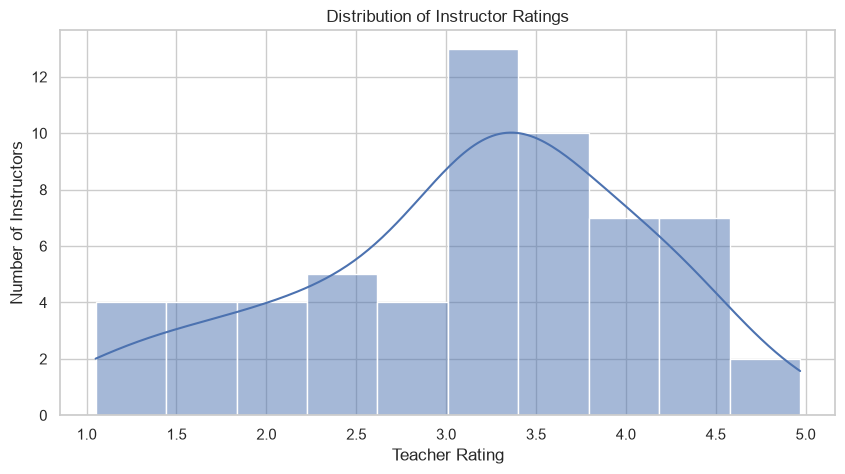

In [211]:
plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    teachers["TeacherRating"],
    bins=10,
    kde=True
)

plt.title(
    "Distribution of Instructor Ratings"
)

plt.xlabel(
    "Teacher Rating"
)

plt.ylabel(
    "Number of Instructors"
)

plt.show()

## Teacher rating boxplot

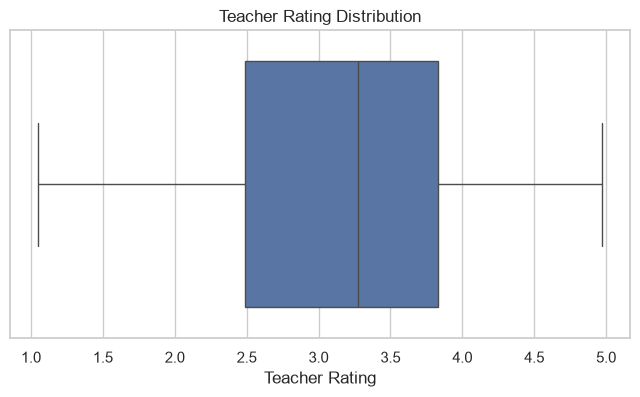

In [212]:
plt.figure(
    figsize=(8, 4)
)

sns.boxplot(
    x=teachers["TeacherRating"]
)

plt.title(
    "Teacher Rating Distribution"
)

plt.xlabel(
    "Teacher Rating"
)

plt.show()

## Course rating distribution

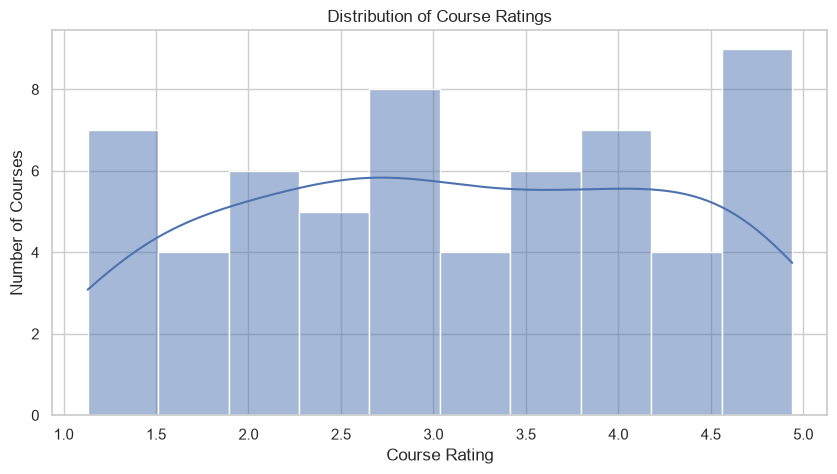

In [213]:
plt.figure(
    figsize=(10, 5)
)

sns.histplot(
    courses["CourseRating"],
    bins=10,
    kde=True
)

plt.title(
    "Distribution of Course Ratings"
)

plt.xlabel(
    "Course Rating"
)

plt.ylabel(
    "Number of Courses"
)

plt.show()

## Experience vs Teacher Rating

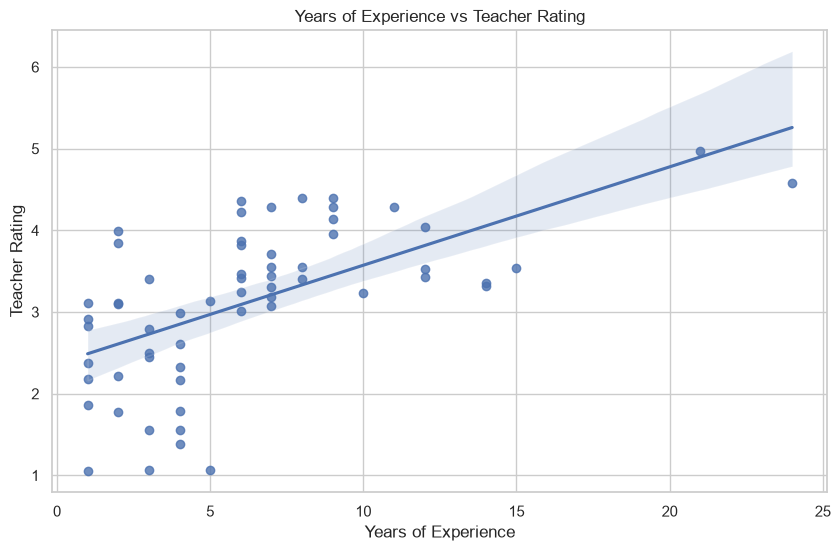

In [214]:
plt.figure(
    figsize=(10, 6)
)

sns.regplot(
    data=teachers,
    x="YearsOfExperience",
    y="TeacherRating"
)

plt.title(
    "Years of Experience vs Teacher Rating"
)

plt.xlabel(
    "Years of Experience"
)

plt.ylabel(
    "Teacher Rating"
)

plt.show()

## Experience correlation

In [215]:
experience_teacher_corr = teachers[
    "YearsOfExperience"
].corr(
    teachers["TeacherRating"]
)

print(
    "Experience ↔ Teacher Rating:",
    round(
        experience_teacher_corr,
        3
    )
)

Experience ↔ Teacher Rating: 0.598


## Experience vs Course Rating

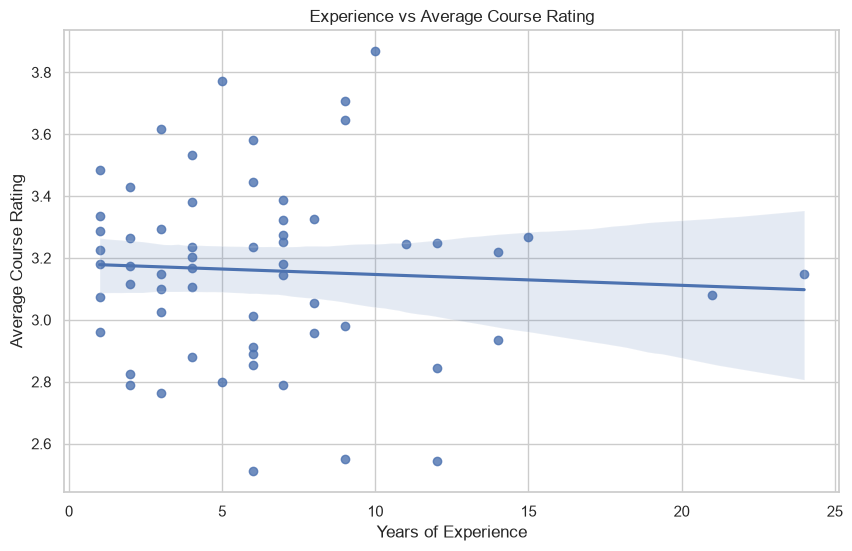

In [216]:
plt.figure(
    figsize=(10, 6)
)

sns.regplot(
    data=instructor_df,
    x="YearsOfExperience",
    y="AverageCourseRating"
)

plt.title(
    "Experience vs Average Course Rating"
)

plt.xlabel(
    "Years of Experience"
)

plt.ylabel(
    "Average Course Rating"
)

plt.show()

## Experience/course correlation

In [217]:
experience_course_corr = instructor_df[
    "YearsOfExperience"
].corr(
    instructor_df[
        "AverageCourseRating"
    ]
)

print(
    "Experience ↔ Course Rating:",
    round(
        experience_course_corr,
        3
    )
)

Experience ↔ Course Rating: -0.057


## Teacher Rating vs Course Rating

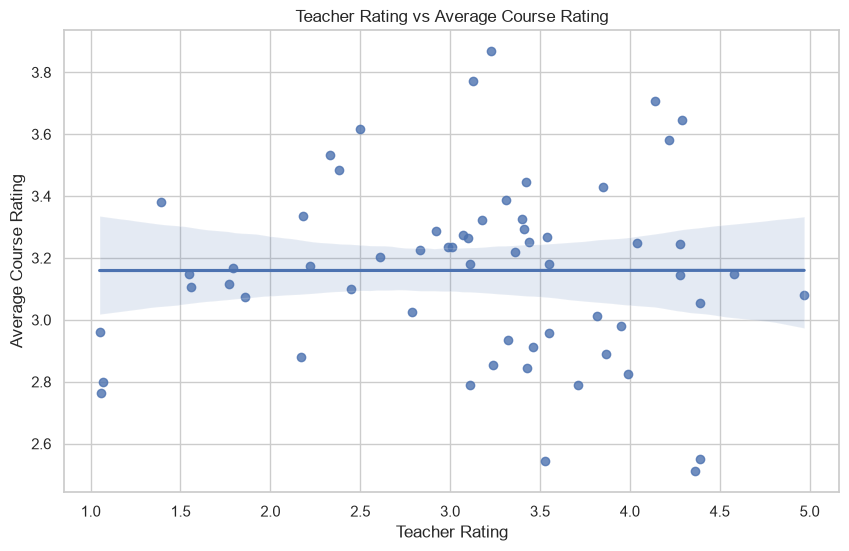

In [218]:
plt.figure(
    figsize=(10, 6)
)

sns.regplot(
    data=instructor_df,
    x="TeacherRating",
    y="AverageCourseRating"
)

plt.title(
    "Teacher Rating vs Average Course Rating"
)

plt.xlabel(
    "Teacher Rating"
)

plt.ylabel(
    "Average Course Rating"
)

plt.show()

## Correlation

In [219]:
teacher_course_corr = instructor_df[
    "TeacherRating"
].corr(
    instructor_df[
        "AverageCourseRating"
    ]
)

print(
    "Teacher Rating ↔ Course Rating:",
    round(
        teacher_course_corr,
        3
    )
)

Teacher Rating ↔ Course Rating: 0.0


## Correlation matrix

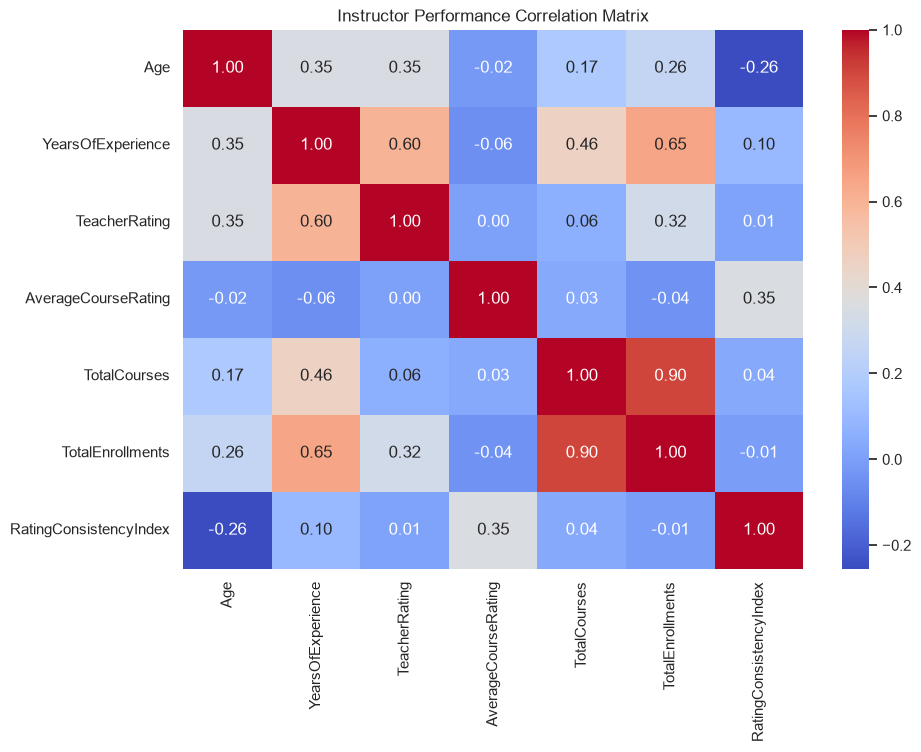

In [220]:
correlation_df = instructor_df[
    [
        "Age",
        "YearsOfExperience",
        "TeacherRating",
        "AverageCourseRating",
        "TotalCourses",
        "TotalEnrollments",
        "RatingConsistencyIndex"
    ]
]

plt.figure(
    figsize=(10, 7)
)

sns.heatmap(
    correlation_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title(
    "Instructor Performance Correlation Matrix"
)

plt.show()

## Expertise distribution

In [221]:
expertise_counts = teachers[
    "Expertise"
].value_counts()

display(
    expertise_counts
)

Expertise
Digital Marketing          11
Cybersecurity               9
Finance                     6
Artificial Intelligence     6
Machine Learning            5
Data Science                5
Project Management          5
Web Development             5
Design                      4
Business                    2
Marketing                   1
Programming                 1
Name: count, dtype: int64

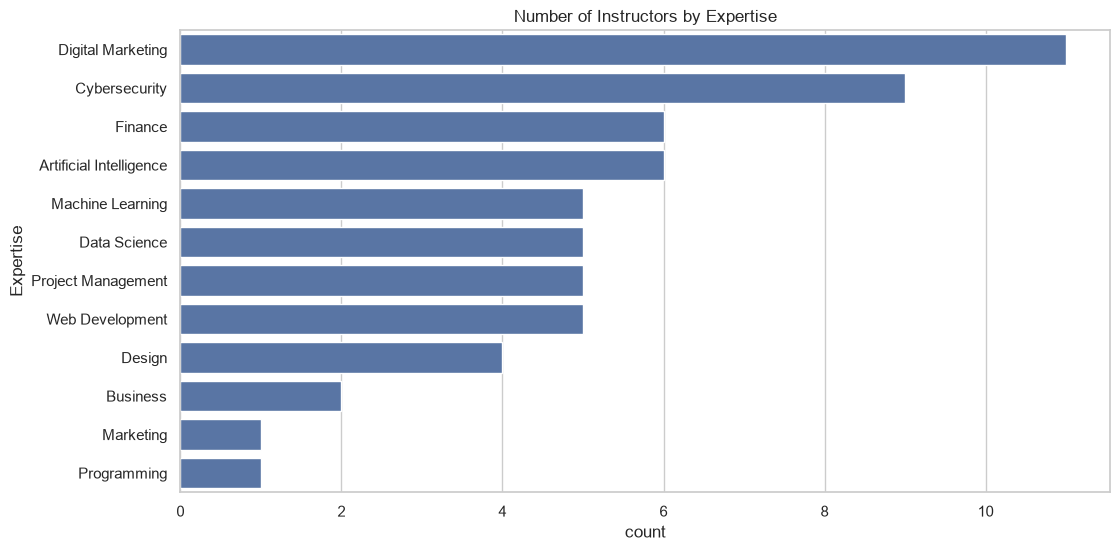

In [222]:
plt.figure(
    figsize=(12, 6)
)

sns.countplot(
    data=teachers,
    y="Expertise",
    order=teachers[
        "Expertise"
    ].value_counts().index
)

plt.title(
    "Number of Instructors by Expertise"
)

plt.show()

## Expertise performance

In [223]:
expertise_analysis = (
    instructor_df
    .groupby("Expertise")
    .agg(
        AverageTeacherRating=(
            "TeacherRating",
            "mean"
        ),

        AverageCourseRating=(
            "AverageCourseRating",
            "mean"
        ),

        TotalEnrollments=(
            "TotalEnrollments",
            "sum"
        ),

        InstructorCount=(
            "TeacherID",
            "nunique"
        )
    )
    .reset_index()
)

display(
    expertise_analysis
)

,Expertise,AverageTeacherRating,AverageCourseRating,TotalEnrollments,InstructorCount
0,Artificial Intelligence,3.173333,3.155289,389,6
1,Business,2.245000,2.804279,258,2
2,Cybersecurity,3.468889,3.038318,3450,9
3,Data Science,3.030000,3.282659,432,5
4,Design,2.290000,3.160022,324,4
5,Digital Marketing,3.050000,3.546759,479,11
6,Finance,3.265000,3.165917,410,6
7,Machine Learning,4.234000,2.775056,3303,5
8,Marketing,4.290000,3.646667,120,1
9,Programming,3.950000,2.980488,123,1


## Expertise vs Teacher Rating

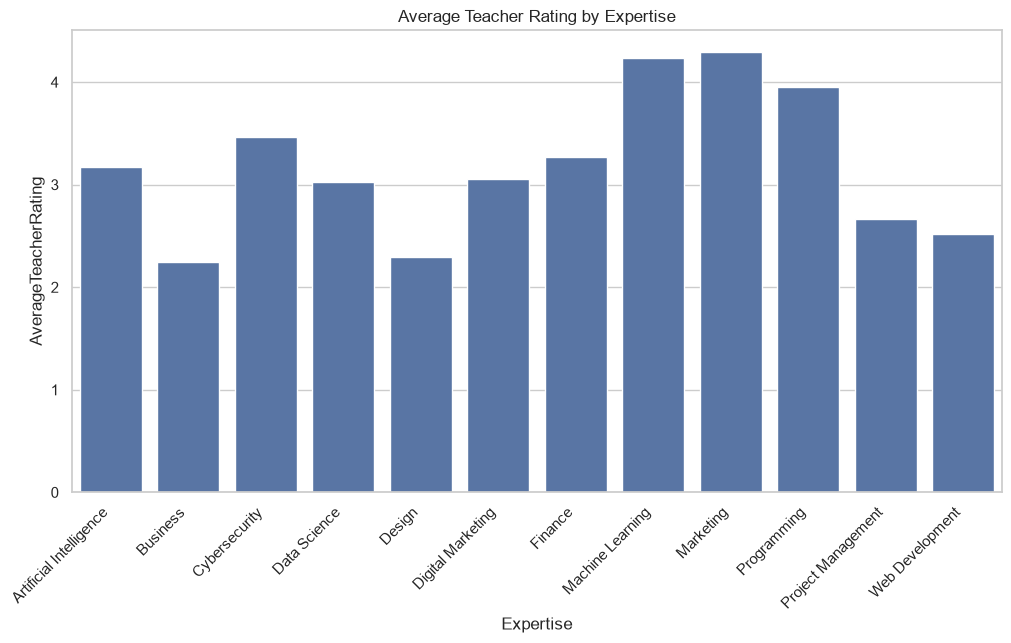

In [224]:
plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=expertise_analysis,
    x="Expertise",
    y="AverageTeacherRating"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Average Teacher Rating by Expertise"
)

plt.show()

## Expertise vs Course Rating

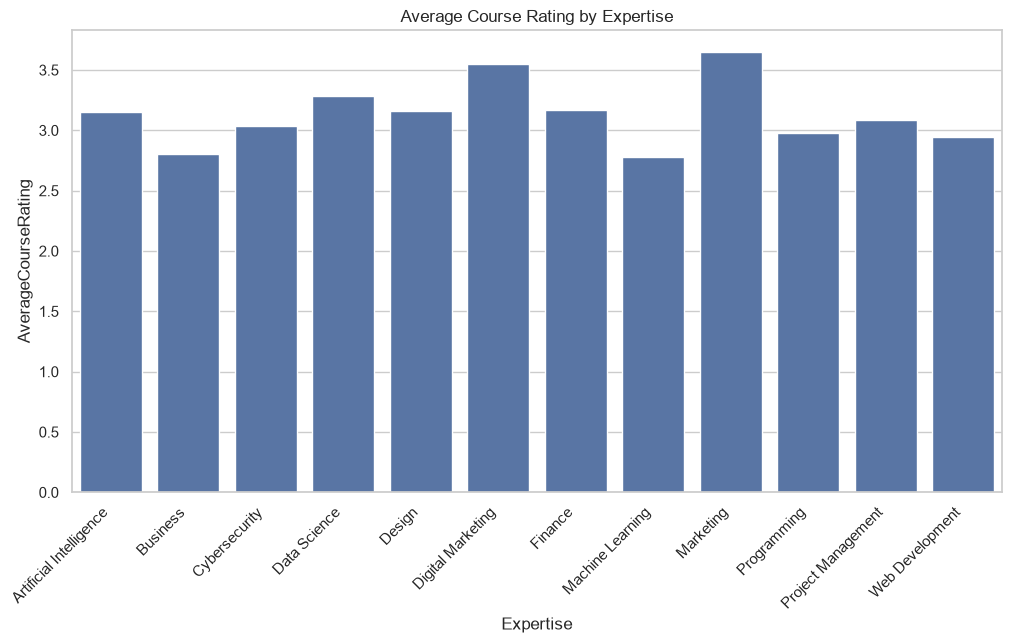

In [225]:
plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=expertise_analysis,
    x="Expertise",
    y="AverageCourseRating"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Average Course Rating by Expertise"
)

plt.show()

## Cell 43 — Expertise vs Enrollments


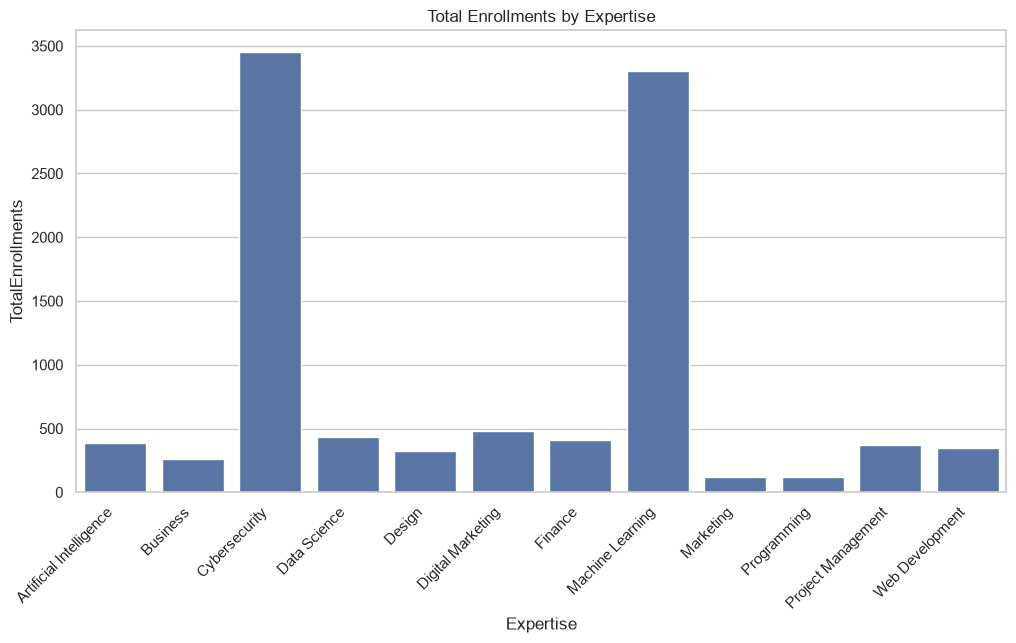

In [226]:
plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=expertise_analysis,
    x="Expertise",
    y="TotalEnrollments"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Total Enrollments by Expertise"
)

plt.show()

## Course Category analysis

In [227]:
category_analysis = (
    master_df
    .groupby("CourseCategory")
    .agg(
        AverageCourseRating=(
            "CourseRating",
            "mean"
        ),

        TotalEnrollments=(
            "TransactionID",
            "count"
        ),

        CourseCount=(
            "CourseID",
            "nunique"
        )
    )
    .reset_index()
)

display(
    category_analysis
)

,CourseCategory,AverageCourseRating,TotalEnrollments,CourseCount
0,Artificial Intelligence,3.122497,829,5
1,Business,2.693685,833,5
2,Cybersecurity,2.975104,819,5
3,Data Science,3.335207,916,5
4,Design,3.179093,827,5
5,Digital Marketing,3.682574,808,5
6,Finance,3.044016,864,5
7,Machine Learning,2.712320,819,5
8,Marketing,3.686253,806,5
9,Programming,3.053945,806,5


## Category ratings

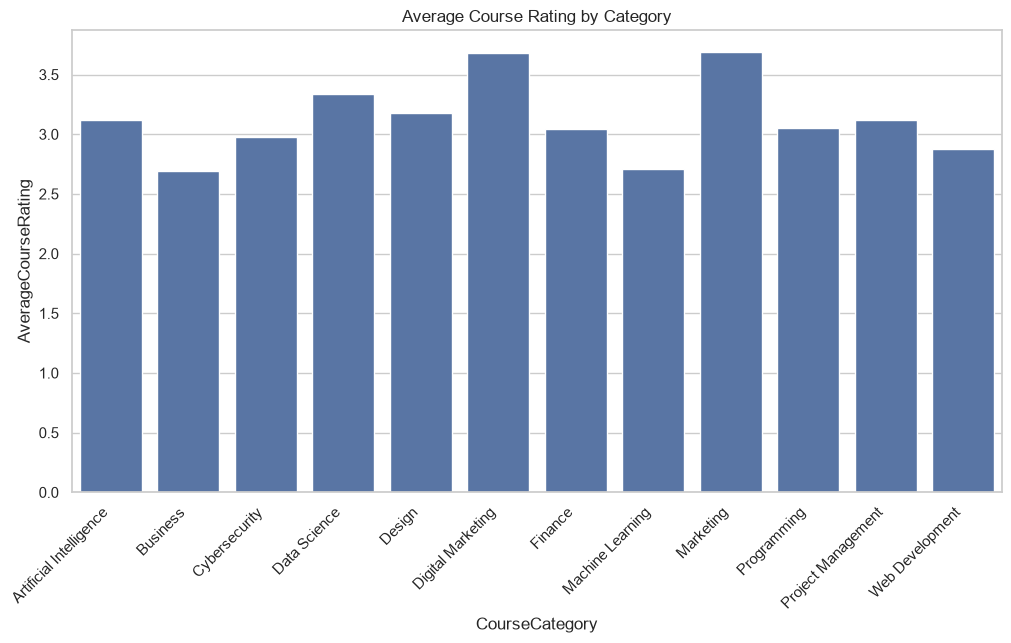

In [228]:
plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=category_analysis,
    x="CourseCategory",
    y="AverageCourseRating"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Average Course Rating by Category"
)

plt.show()

## Category enrollments

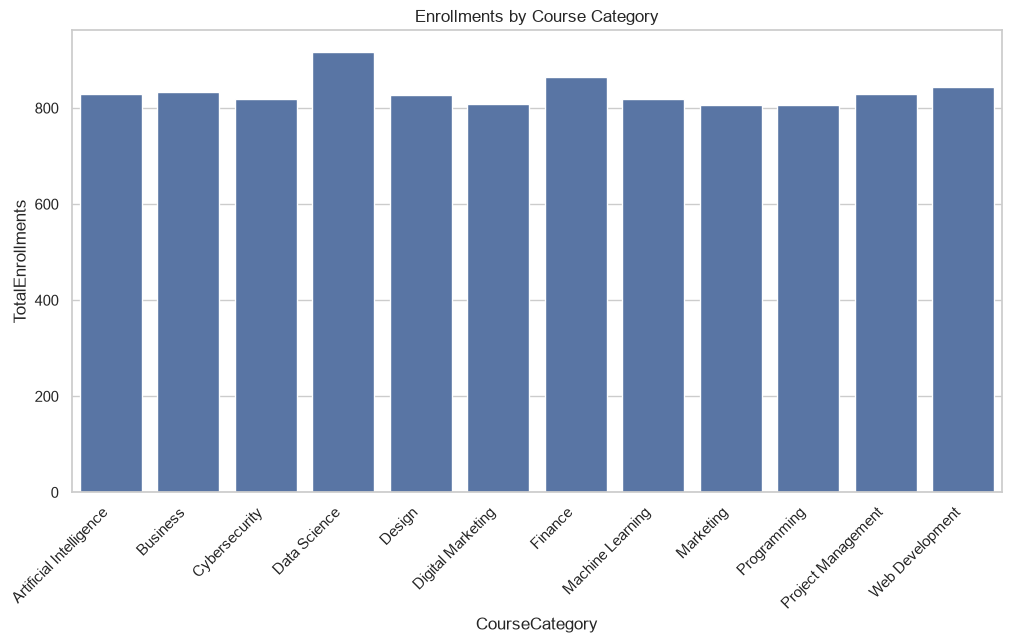

In [229]:
plt.figure(
    figsize=(12, 6)
)

sns.barplot(
    data=category_analysis,
    x="CourseCategory",
    y="TotalEnrollments"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.title(
    "Enrollments by Course Category"
)

plt.show()

## Course level analysis

In [230]:
level_analysis = (
    master_df
    .groupby("CourseLevel")
    .agg(
        AverageCourseRating=(
            "CourseRating",
            "mean"
        ),

        TotalEnrollments=(
            "TransactionID",
            "count"
        ),

        CourseCount=(
            "CourseID",
            "nunique"
        )
    )
    .reset_index()
)

display(
    level_analysis
)

,CourseLevel,AverageCourseRating,TotalEnrollments,CourseCount
0,Advanced,2.819030,3475,21
1,Beginner,3.242888,3573,21
2,Intermediate,3.336653,2952,18


## Course level rating

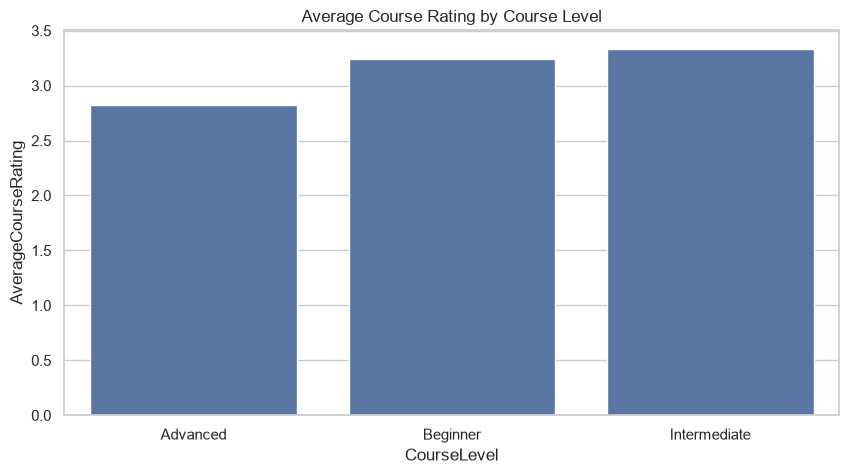

In [231]:
plt.figure(
    figsize=(10, 5)
)

sns.barplot(
    data=level_analysis,
    x="CourseLevel",
    y="AverageCourseRating"
)

plt.title(
    "Average Course Rating by Course Level"
)

plt.show()

## Course Category × Level heatmap

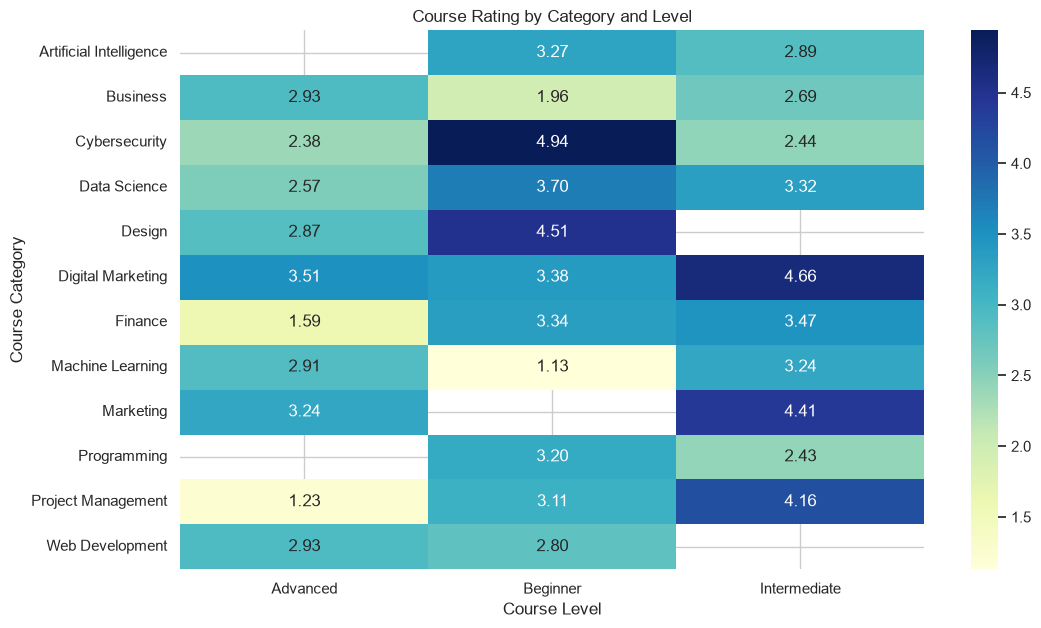

In [232]:
heatmap_data = master_df.pivot_table(
    index="CourseCategory",
    columns="CourseLevel",
    values="CourseRating",
    aggfunc="mean"
)

plt.figure(
    figsize=(12, 7)
)

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title(
    "Course Rating by Category and Level"
)

plt.xlabel(
    "Course Level"
)

plt.ylabel(
    "Course Category"
)

plt.show()

## Gender analysis

In [233]:
gender_analysis = (
    instructor_df
    .groupby("Gender")
    .agg(
        AverageTeacherRating=(
            "TeacherRating",
            "mean"
        ),

        AverageCourseRating=(
            "AverageCourseRating",
            "mean"
        ),

        TotalEnrollments=(
            "TotalEnrollments",
            "sum"
        ),

        InstructorCount=(
            "TeacherID",
            "count"
        )
    )
    .reset_index()
)

display(
    gender_analysis
)

,Gender,AverageTeacherRating,AverageCourseRating,TotalEnrollments,InstructorCount
0,Female,3.231111,3.052702,4926,27
1,Male,3.038182,3.247446,5074,33


## Gender vs Teacher Rating

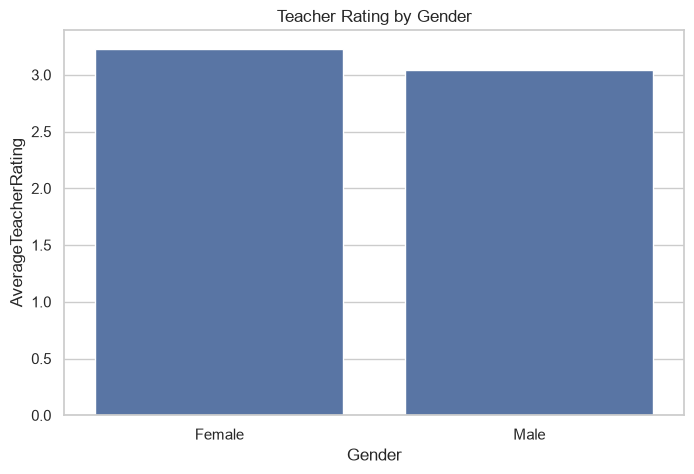

In [234]:
plt.figure(
    figsize=(8, 5)
)

sns.barplot(
    data=gender_analysis,
    x="Gender",
    y="AverageTeacherRating"
)

plt.title(
    "Teacher Rating by Gender"
)

plt.show()

## Performance tiers

In [235]:
def performance_tier(rating):

    if rating >= 4.5:
        return "High"

    elif rating >= 4.0:
        return "Medium"

    else:
        return "Low"


instructor_df[
    "PerformanceTier"
] = instructor_df[
    "TeacherRating"
].apply(
    performance_tier
)

## Performance tier distribution

In [236]:
tier_counts = (
    instructor_df[
        "PerformanceTier"
    ]
    .value_counts()
)

display(
    tier_counts
)

PerformanceTier
Low       49
Medium     9
High       2
Name: count, dtype: int64

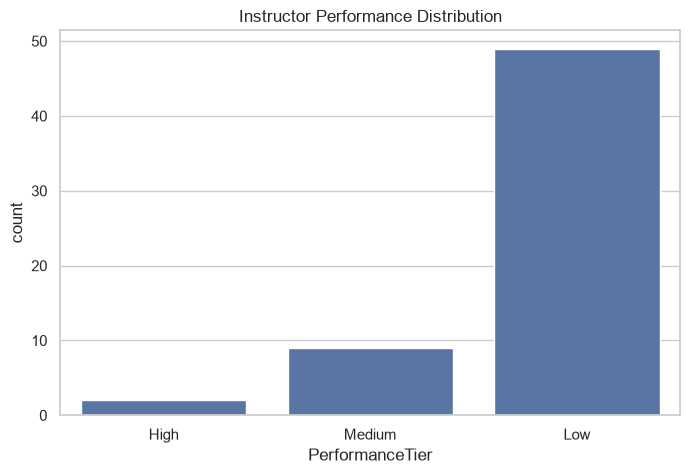

In [237]:
plt.figure(
    figsize=(8, 5)
)

sns.countplot(
    data=instructor_df,
    x="PerformanceTier",
    order=[
        "High",
        "Medium",
        "Low"
    ]
)

plt.title(
    "Instructor Performance Distribution"
)

plt.show()

## Enrollment by performance tier

In [238]:
tier_enrollment = (
    instructor_df
    .groupby("PerformanceTier")
    ["TotalEnrollments"]
    .mean()
    .reindex(
        [
            "High",
            "Medium",
            "Low"
        ]
    )
)

display(
    tier_enrollment
)

PerformanceTier
High      3043.000000
Medium      81.555556
Low         64.897959
Name: TotalEnrollments, dtype: float64

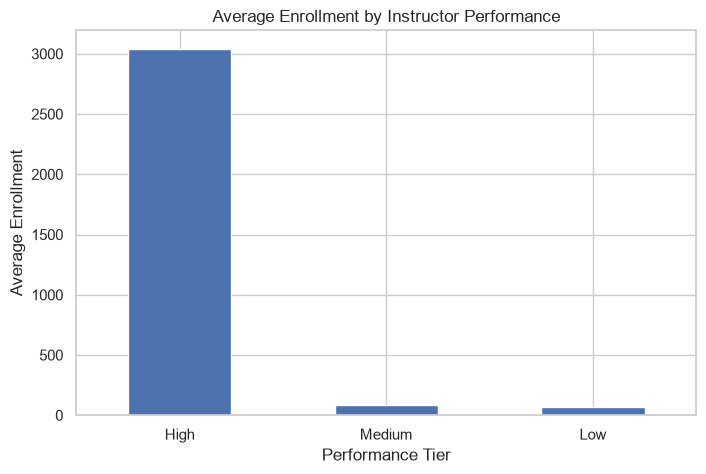

In [239]:
plt.figure(
    figsize=(8, 5)
)

tier_enrollment.plot(
    kind="bar"
)

plt.title(
    "Average Enrollment by Instructor Performance"
)

plt.xlabel(
    "Performance Tier"
)

plt.ylabel(
    "Average Enrollment"
)

plt.xticks(
    rotation=0
)

plt.show()

## Enrollment Influence Ratio

In [240]:
high_enrollment = instructor_df[
    instructor_df[
        "PerformanceTier"
    ] == "High"
][
    "TotalEnrollments"
].mean()

low_enrollment = instructor_df[
    instructor_df[
        "PerformanceTier"
    ] == "Low"
][
    "TotalEnrollments"
].mean()

In [241]:
if low_enrollment > 0:

    enrollment_influence_ratio = (
        high_enrollment /
        low_enrollment
    )

else:

    enrollment_influence_ratio = np.nan


print(
    "Enrollment Influence Ratio:",
    round(
        enrollment_influence_ratio,
        2
    )
)

Enrollment Influence Ratio: 46.89


## Instructor Performance Score

In [242]:
from sklearn.preprocessing import MinMaxScaler

score_columns = [
    "TeacherRating",
    "AverageCourseRating",
    "TotalEnrollments",
    "YearsOfExperience"
]

scaler = MinMaxScaler()

normalized = scaler.fit_transform(
    instructor_df[
        score_columns
    ]
)

normalized_df = pd.DataFrame(
    normalized,
    columns=[
        "TeacherRatingNorm",
        "CourseRatingNorm",
        "EnrollmentNorm",
        "ExperienceNorm"
    ],
    index=instructor_df.index
)

instructor_df = pd.concat(
    [
        instructor_df,
        normalized_df
    ],
    axis=1
)

## Calculate Performance Score

In [243]:
instructor_df[
    "PerformanceScore"
] = (

    0.40 *
    instructor_df[
        "TeacherRatingNorm"
    ]

    +

    0.30 *
    instructor_df[
        "CourseRatingNorm"
    ]

    +

    0.20 *
    instructor_df[
        "EnrollmentNorm"
    ]

    +

    0.10 *
    instructor_df[
        "ExperienceNorm"
    ]

) * 100

## Instructor leaderboard

In [244]:
leaderboard = instructor_df.sort_values(
    "PerformanceScore",
    ascending=False
).copy()

leaderboard[
    [
        "TeacherName",
        "Expertise",
        "YearsOfExperience",
        "TeacherRating",
        "AverageCourseRating",
        "TotalCourses",
        "TotalEnrollments",
        "PerformanceTier",
        "PerformanceScore"
    ]
].head(20)

,TeacherName,Expertise,YearsOfExperience,TeacherRating,AverageCourseRating,TotalCourses,TotalEnrollments,PerformanceTier,PerformanceScore
41,Yolanda Levine,Machine Learning,21,4.97,3.079252,55,3061,High,81.260692
39,Kimberly Miller,Cybersecurity,24,4.58,3.147997,55,3025,High,79.868026
52,Aaron Kirby,Marketing,9,4.29,3.646667,9,120,Medium,62.285579
1,Jill Day,Digital Marketing,9,4.14,3.708824,9,68,Medium,61.786589
23,Michael Kim,Digital Marketing,6,4.22,3.582807,8,57,Medium,58.440607
19,Tara Reynolds,Digital Marketing,10,3.23,3.868000,14,25,Low,56.171108
17,Kari Pierce,Project Management,11,4.28,3.246237,8,93,Medium,54.024008
32,Wesley Garcia,Design,12,4.04,3.247956,8,137,Medium,52.337487
34,Sharon Jackson,Digital Marketing,5,3.13,3.772895,14,38,Low,50.960106
53,Shelby Patrick,Artificial Intelligence,7,4.28,3.146304,9,46,Medium,49.766502


## Top 10 instructors

In [245]:
top_10 = leaderboard.head(10)

display(
    top_10[
        [
            "TeacherName",
            "Expertise",
            "TeacherRating",
            "AverageCourseRating",
            "TotalEnrollments",
            "PerformanceScore"
        ]
    ]
)

,TeacherName,Expertise,TeacherRating,AverageCourseRating,TotalEnrollments,PerformanceScore
41,Yolanda Levine,Machine Learning,4.97,3.079252,3061,81.260692
39,Kimberly Miller,Cybersecurity,4.58,3.147997,3025,79.868026
52,Aaron Kirby,Marketing,4.29,3.646667,120,62.285579
1,Jill Day,Digital Marketing,4.14,3.708824,68,61.786589
23,Michael Kim,Digital Marketing,4.22,3.582807,57,58.440607
19,Tara Reynolds,Digital Marketing,3.23,3.868000,25,56.171108
17,Kari Pierce,Project Management,4.28,3.246237,93,54.024008
32,Wesley Garcia,Design,4.04,3.247956,137,52.337487
34,Sharon Jackson,Digital Marketing,3.13,3.772895,38,50.960106
53,Shelby Patrick,Artificial Intelligence,4.28,3.146304,46,49.766502


## Top instructor chart

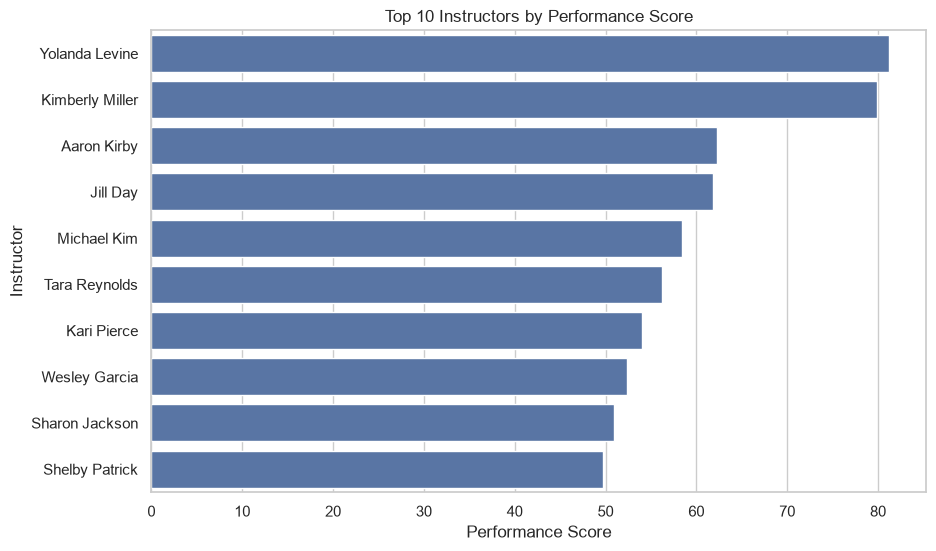

In [246]:
plt.figure(
    figsize=(10, 6)
)

sns.barplot(
    data=top_10,
    x="PerformanceScore",
    y="TeacherName"
)

plt.title(
    "Top 10 Instructors by Performance Score"
)

plt.xlabel(
    "Performance Score"
)

plt.ylabel(
    "Instructor"
)

plt.show()

## Lowest performing instructors

In [247]:
bottom_10 = leaderboard.tail(10).sort_values(
    "PerformanceScore"
)

display(
    bottom_10[
        [
            "TeacherName",
            "Expertise",
            "TeacherRating",
            "AverageCourseRating",
            "TotalEnrollments",
            "PerformanceScore"
        ]
    ]
)

,TeacherName,Expertise,TeacherRating,AverageCourseRating,TotalEnrollments,PerformanceScore
27,Timothy Bailey,Business,1.06,2.765155,161,7.502159
44,Emily Gutierrez,Web Development,1.07,2.800536,56,8.564591
42,John Williams,Project Management,1.05,2.960735,68,10.241526
2,Amber Torres,Design,1.56,3.107627,59,19.937690
26,Laurie Michael,Artificial Intelligence,1.55,3.149774,133,20.819679
24,Justin Pham,Web Development,2.17,2.881458,48,21.090394
50,John Obrien,Design,1.77,3.116349,63,21.430114
30,Brenda Mercer,Cybersecurity,1.86,3.073354,164,21.628210
46,Brad Griffin,Design,1.79,3.168154,65,23.662048
35,Brenda Mclean,Digital Marketing,1.39,3.382174,46,24.186160


## ML: Prepare dataset

In [248]:
ml_df = master_df[
    [
        "TeacherRating",
        "Age",
        "YearsOfExperience",
        "Gender",
        "Expertise",
        "CourseCategory",
        "CourseLevel",
        "CourseRating"
    ]
].dropna()

In [249]:
ml_df.shape

(10000, 8)

## Define X and y

In [250]:
X = ml_df[
    [
        "TeacherRating",
        "Age",
        "YearsOfExperience",
        "Gender",
        "Expertise",
        "CourseCategory",
        "CourseLevel"
    ]
]

y = ml_df[
    "CourseRating"
]

## Train/Test split

In [251]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(
    "Training records:",
    X_train.shape[0]
)

print(
    "Testing records:",
    X_test.shape[0]
)

Training records: 8000
Testing records: 2000


## Define categorical features

In [252]:
categorical_features = [
    "Gender",
    "Expertise",
    "CourseCategory",
    "CourseLevel"
]

numeric_features = [
    "TeacherRating",
    "Age",
    "YearsOfExperience"
]

## Preprocessing pipeline

In [253]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        ),

        (
            "numeric",
            "passthrough",
            numeric_features
        )
    ]
)

## Random Forest model

In [254]:
rf_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                max_depth=10
            )
        )
    ]
)

In [255]:
rf_model.fit(
    X_train,
    y_train
)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](7,)","['TeacherRating','Age','YearsOfExperience',...,'Expertise', 'CourseCategory','CourseLevel']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,7
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed t

## Predictions

In [256]:
y_pred = rf_model.predict(
    X_test
)

## Evaluate model

In [257]:
mae = mean_absolute_error(
    y_test,
    y_pred
)

rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

r2 = r2_score(
    y_test,
    y_pred
)

print(
    "Random Forest Results"
)

print(
    "MAE:",
    round(mae, 4)
)

print(
    "RMSE:",
    round(rmse, 4)
)

print(
    "R²:",
    round(r2, 4)
)

Random Forest Results
MAE: 0.6999
RMSE: 0.9217
R²: 0.3621


## Actual vs predicted

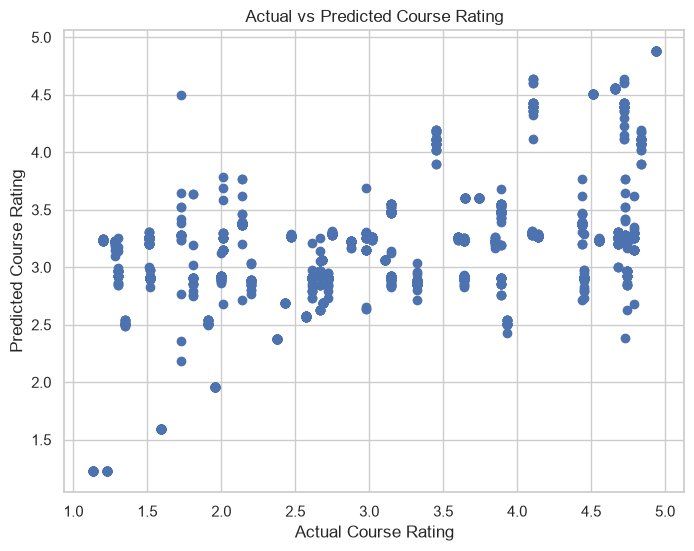

In [258]:
plt.figure(
    figsize=(8, 6)
)

plt.scatter(
    y_test,
    y_pred
)

plt.xlabel(
    "Actual Course Rating"
)

plt.ylabel(
    "Predicted Course Rating"
)

plt.title(
    "Actual vs Predicted Course Rating"
)

plt.show()

## Compare multiple ML models

In [259]:
linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

## Gradient Boosting

In [260]:
gb_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                random_state=42
            )
        )
    ]
)

gb_model.fit(
    X_train,
    y_train
)

gb_pred = gb_model.predict(
    X_test
)

gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)

gb_r2 = r2_score(
    y_test,
    gb_pred
)

## Compare models

In [261]:
model_results = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        mae,
        gb_mae
    ],

    "RMSE": [
        linear_rmse,
        rmse,
        gb_rmse
    ],

    "R2": [
        linear_r2,
        r2,
        gb_r2
    ]
})

display(
    model_results.round(4)
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.8975,1.0780,0.1276
1,Random Forest,0.6999,0.9217,0.3621
2,Gradient Boosting,0.7059,0.9180,0.3672


## Select best model

In [262]:
best_model = model_results.sort_values(
    "RMSE"
).iloc[0]

print(
    "Best Model:",
    best_model["Model"]
)

Best Model: Gradient Boosting


## Feature importance

In [263]:
rf_preprocessor = rf_model.named_steps[
    "preprocessor"
]

rf_estimator = rf_model.named_steps[
    "model"
]

In [264]:
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

In [265]:
importance_df = pd.DataFrame({

    "Feature": feature_names,

    "Importance": rf_estimator.feature_importances_

})

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False
)

display(
    importance_df.head(20)
)

,Feature,Importance
24,categorical__CourseCategory_Project Management,0.131017
28,categorical__CourseLevel_Intermediate,0.120147
16,categorical__CourseCategory_Cybersecurity,0.116776
26,categorical__CourseLevel_Advanced,0.103750
22,categorical__CourseCategory_Marketing,0.096409
27,categorical__CourseLevel_Beginner,0.074989
20,categorical__CourseCategory_Finance,0.065865
15,categorical__CourseCategory_Business,0.056679
18,categorical__CourseCategory_Design,0.051053
21,categorical__CourseCategory_Machine Learning,0.046703


## Feature importance graph

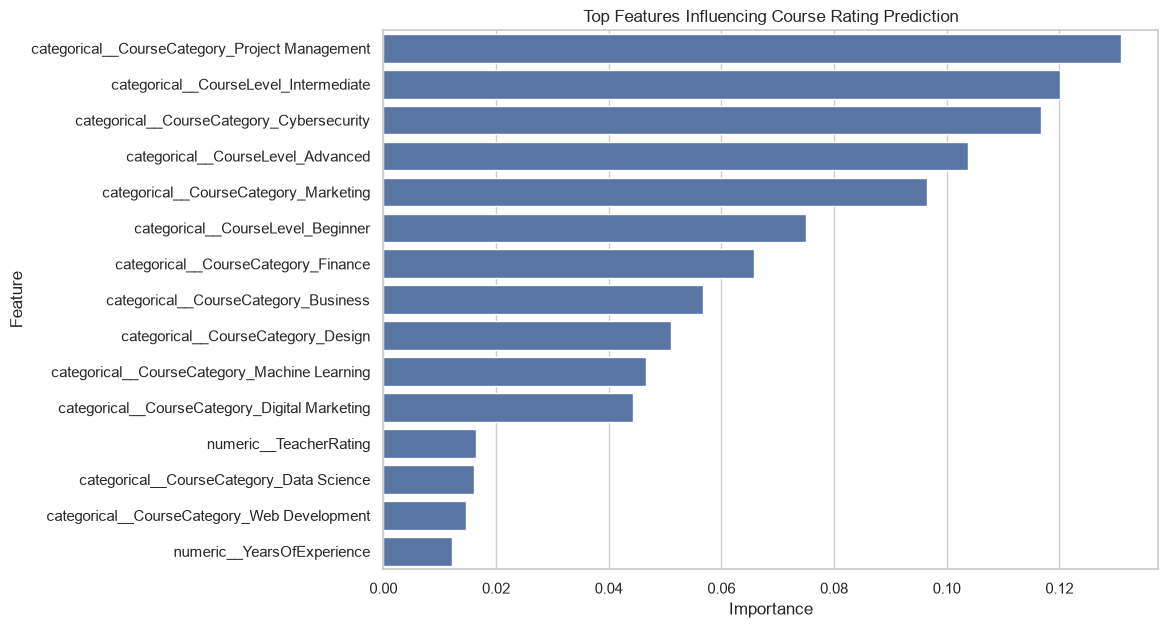

In [266]:
top_features = importance_df.head(15)

plt.figure(
    figsize=(10, 7)
)

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Features Influencing Course Rating Prediction"
)

plt.show()

## Predict a new course

In [267]:
new_course = pd.DataFrame({

    "TeacherRating": [4.6],

    "Age": [35],

    "YearsOfExperience": [8],

    "Gender": ["Male"],

    "Expertise": ["Python"],

    "CourseCategory": ["Programming"],

    "CourseLevel": ["Intermediate"]
})

In [268]:
prediction = rf_model.predict(
    new_course
)[0]

prediction = np.clip(
    prediction,
    0,
    5
)

print(
    f"Predicted Course Rating: "
    f"{prediction:.2f} / 5"
)

Predicted Course Rating: 2.69 / 5


## Convert prediction into quality category

In [269]:
if prediction >= 4.5:

    quality = "HIGH QUALITY"

elif prediction >= 4.0:

    quality = "MEDIUM QUALITY"

else:

    quality = "NEEDS IMPROVEMENT"


print(
    "Predicted Quality:",
    quality
)

Predicted Quality: NEEDS IMPROVEMENT


## Save master dataset

In [270]:
master_df.to_csv(
    "EduPro_Master_Dataset.csv",
    index=False
)

## Save instructor analysis

In [271]:
instructor_df.to_csv(
    "EduPro_Instructor_Analysis.csv",
    index=False
)

## Save ML model

In [272]:
import joblib

joblib.dump(
    rf_model,
    "EduPro_Course_Rating_Model.pkl"
)

print(
    "Model saved successfully."
)

Model saved successfully.


## Generate automatic insights

In [273]:
print("========== EDUPRO INSIGHTS ==========\n")


# Top expertise
top_expertise = expertise_analysis.sort_values(
    "AverageCourseRating",
    ascending=False
).iloc[0]

print(
    "1. Highest-rated expertise:",
    top_expertise["Expertise"]
)

print(
    "   Average Course Rating:",
    round(
        top_expertise[
            "AverageCourseRating"
        ],
        2
    )
)


# Top category
top_category = category_analysis.sort_values(
    "AverageCourseRating",
    ascending=False
).iloc[0]

print(
    "\n2. Highest-rated course category:",
    top_category["CourseCategory"]
)

print(
    "   Average Rating:",
    round(
        top_category[
            "AverageCourseRating"
        ],
        2
    )
)


# Top level
top_level = level_analysis.sort_values(
    "AverageCourseRating",
    ascending=False
).iloc[0]

print(
    "\n3. Highest-rated course level:",
    top_level["CourseLevel"]
)

print(
    "   Average Rating:",
    round(
        top_level[
            "AverageCourseRating"
        ],
        2
    )
)


# Experience
print(
    "\n4. Experience ↔ Teacher Rating:",
    round(
        experience_teacher_corr,
        3
    )
)

print(
    "5. Experience ↔ Course Rating:",
    round(
        experience_course_corr,
        3
    )
)


# Teacher vs course
print(
    "6. Teacher Rating ↔ Course Rating:",
    round(
        teacher_course_corr,
        3
    )
)


# Top instructor
top_instructor = leaderboard.iloc[0]

print(
    "\n7. Top-performing instructor:",
    top_instructor["TeacherName"]
)

print(
    "   Performance Score:",
    round(
        top_instructor[
            "PerformanceScore"
        ],
        2
    )
)

print(
    "\n====================================="
)

========== EDUPRO INSIGHTS ==========

1. Highest-rated expertise: Marketing
   Average Course Rating: 3.65

2. Highest-rated course category: Marketing
   Average Rating: 3.69

3. Highest-rated course level: Intermediate
   Average Rating: 3.34

4. Experience ↔ Teacher Rating: 0.598
5. Experience ↔ Course Rating: -0.057
6. Teacher Rating ↔ Course Rating: 0.0

7. Top-performing instructor: Yolanda Levine
   Performance Score: 81.26



### Verify Top/Bottom Instructors

In [274]:
# Top 10 instructors
top_instructors = instructor_df.sort_values(
    "PerformanceScore",
    ascending=False
).head(10)

display(
    top_instructors[
        [
            "TeacherName",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating",
            "AverageCourseRating",
            "TotalCourses",
            "TotalEnrollments",
            "RatingConsistencyPercent",
            "PerformanceScore"
        ]
    ]
)

,TeacherName,Expertise,YearsOfExperience,TeacherRating,AverageCourseRating,TotalCourses,TotalEnrollments,RatingConsistencyPercent,PerformanceScore
41,Yolanda Levine,Machine Learning,21,4.97,3.079252,55,3061,76.557732,81.260692
39,Kimberly Miller,Cybersecurity,24,4.58,3.147997,55,3025,77.154732,79.868026
52,Aaron Kirby,Marketing,9,4.29,3.646667,9,120,78.958204,62.285579
1,Jill Day,Digital Marketing,9,4.14,3.708824,9,68,81.412232,61.786589
23,Michael Kim,Digital Marketing,6,4.22,3.582807,8,57,82.318139,58.440607
19,Tara Reynolds,Digital Marketing,10,3.23,3.868000,14,25,79.306442,56.171108
17,Kari Pierce,Project Management,11,4.28,3.246237,8,93,69.778514,54.024008
32,Wesley Garcia,Design,12,4.04,3.247956,8,137,77.605461,52.337487
34,Sharon Jackson,Digital Marketing,5,3.13,3.772895,14,38,81.619287,50.960106
53,Shelby Patrick,Artificial Intelligence,7,4.28,3.146304,9,46,77.409762,49.766502


In [275]:
bottom_instructors = instructor_df.sort_values(
    "PerformanceScore",
    ascending=True
).head(10)

display(
    bottom_instructors[
        [
            "TeacherName",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating",
            "AverageCourseRating",
            "TotalCourses",
            "TotalEnrollments",
            "RatingConsistencyPercent",
            "PerformanceScore"
        ]
    ]
)

,TeacherName,Expertise,YearsOfExperience,TeacherRating,AverageCourseRating,TotalCourses,TotalEnrollments,RatingConsistencyPercent,PerformanceScore
27,Timothy Bailey,Business,3,1.06,2.765155,16,161,85.004266,7.502159
44,Emily Gutierrez,Web Development,5,1.07,2.800536,17,56,75.453127,8.564591
42,John Williams,Project Management,1,1.05,2.960735,14,68,71.197237,10.241526
2,Amber Torres,Design,4,1.56,3.107627,15,59,78.809034,19.937690
26,Laurie Michael,Artificial Intelligence,3,1.55,3.149774,13,133,77.261933,20.819679
24,Justin Pham,Web Development,4,2.17,2.881458,15,48,76.717060,21.090394
50,John Obrien,Design,2,1.77,3.116349,14,63,74.505603,21.430114
30,Brenda Mercer,Cybersecurity,1,1.86,3.073354,15,164,73.789757,21.628210
46,Brad Griffin,Design,4,1.79,3.168154,14,65,76.277835,23.662048
35,Brenda Mclean,Digital Marketing,4,1.39,3.382174,15,46,76.361917,24.186160


### Find Most Consistent Instructors

In [276]:
most_consistent = instructor_df.sort_values(
    "RatingConsistencyIndex",
    ascending=False
).head(10)

display(
    most_consistent[
        [
            "TeacherName",
            "TeacherRating",
            "AverageCourseRating",
            "CourseRatingStd",
            "RatingConsistencyPercent"
        ]
    ]
)

,TeacherName,TeacherRating,AverageCourseRating,CourseRatingStd,RatingConsistencyPercent
7,Steven Walker,3.54,3.267218,0.506160,89.876809
9,Frances Sanchez,2.18,3.335062,0.704608,85.907835
15,David Carlson,2.92,3.286389,0.740246,85.195089
27,Timothy Bailey,1.06,2.765155,0.749787,85.004266
56,Brittany Scott,3.44,3.251020,0.824465,83.510698
51,Susan Johnson,3.43,2.843402,0.831318,83.373643
14,John Armstrong,3.07,3.273607,0.853319,82.933619
23,Michael Kim,4.22,3.582807,0.884093,82.318139
34,Sharon Jackson,3.13,3.772895,0.919036,81.619287
40,Kevin Simpson,3.55,3.179318,0.928986,81.420271


### Find Instructors Needing Improvement

In [277]:
improvement_needed = instructor_df[
    (
        instructor_df["TeacherRating"] < 4
    ) |
    (
        instructor_df["AverageCourseRating"] < 3.5
    )
].sort_values(
    "PerformanceScore"
)

display(
    improvement_needed[
        [
            "TeacherName",
            "Expertise",
            "YearsOfExperience",
            "TeacherRating",
            "AverageCourseRating",
            "RatingConsistencyPercent",
            "PerformanceScore"
        ]
    ].head(20)
)

,TeacherName,Expertise,YearsOfExperience,TeacherRating,AverageCourseRating,RatingConsistencyPercent,PerformanceScore
27,Timothy Bailey,Business,3,1.06,2.765155,85.004266,7.502159
44,Emily Gutierrez,Web Development,5,1.07,2.800536,75.453127,8.564591
42,John Williams,Project Management,1,1.05,2.960735,71.197237,10.241526
2,Amber Torres,Design,4,1.56,3.107627,78.809034,19.937690
26,Laurie Michael,Artificial Intelligence,3,1.55,3.149774,77.261933,20.819679
24,Justin Pham,Web Development,4,2.17,2.881458,76.717060,21.090394
50,John Obrien,Design,2,1.77,3.116349,74.505603,21.430114
30,Brenda Mercer,Cybersecurity,1,1.86,3.073354,73.789757,21.628210
46,Brad Griffin,Design,4,1.79,3.168154,76.277835,23.662048
35,Brenda Mclean,Digital Marketing,4,1.39,3.382174,76.361917,24.186160


### Experience Groups

In [278]:
instructor_df["ExperienceGroup"] = pd.cut(
    instructor_df["YearsOfExperience"],
    bins=[
        -1,
        2,
        5,
        10,
        np.inf
    ],
    labels=[
        "0-2 Years",
        "3-5 Years",
        "6-10 Years",
        "10+ Years"
    ]
)

In [279]:
experience_analysis = (
    instructor_df
    .groupby("ExperienceGroup", observed=True)
    .agg(
        AverageTeacherRating=(
            "TeacherRating",
            "mean"
        ),
        AverageCourseRating=(
            "AverageCourseRating",
            "mean"
        ),
        AverageEnrollment=(
            "TotalEnrollments",
            "mean"
        ),
        InstructorCount=(
            "TeacherID",
            "count"
        )
    )
    .reset_index()
)

display(experience_analysis)

,ExperienceGroup,AverageTeacherRating,AverageCourseRating,AverageEnrollment,InstructorCount
0,0-2 Years,2.643846,3.164886,68.384615,13
1,3-5 Years,2.186667,3.202214,66.866667,15
2,6-10 Years,3.707826,3.168894,60.217391,23
3,10+ Years,3.894444,3.058599,747.000000,9


### Experience Group Visualization

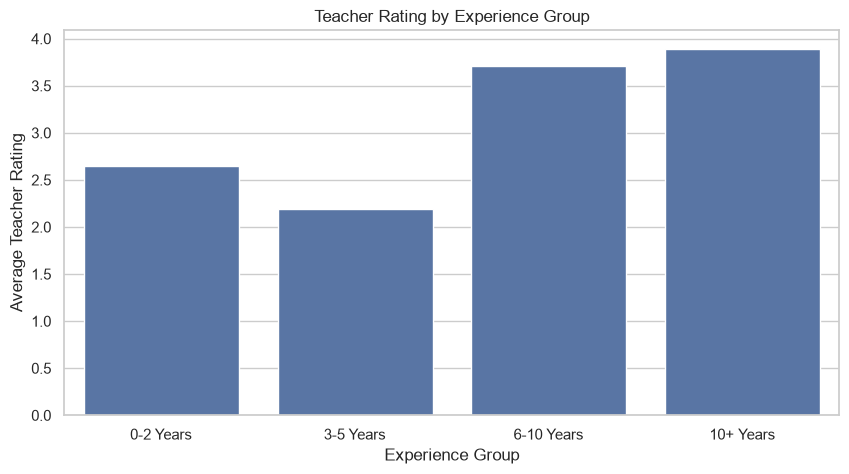

In [280]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=experience_analysis,
    x="ExperienceGroup",
    y="AverageTeacherRating"
)

plt.title(
    "Teacher Rating by Experience Group"
)

plt.xlabel(
    "Experience Group"
)

plt.ylabel(
    "Average Teacher Rating"
)

plt.show()

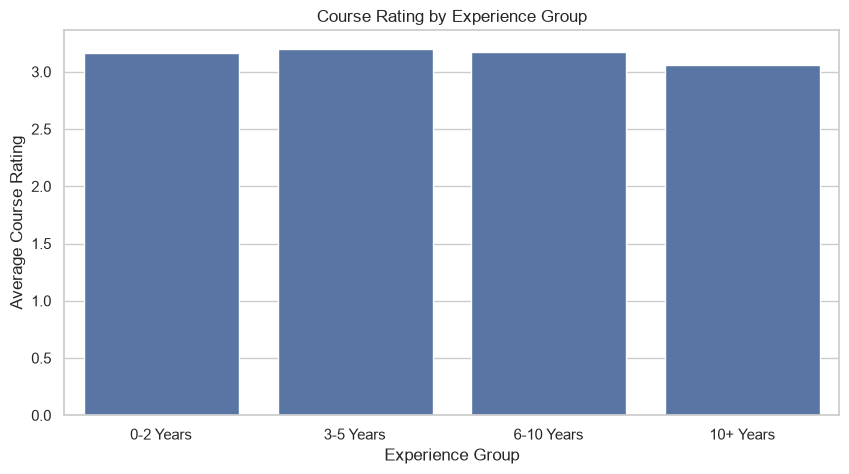

In [281]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=experience_analysis,
    x="ExperienceGroup",
    y="AverageCourseRating"
)

plt.title(
    "Course Rating by Experience Group"
)

plt.xlabel(
    "Experience Group"
)

plt.ylabel(
    "Average Course Rating"
)

plt.show()

### Course-Level × Expertise Analysis

In [282]:
expertise_level = master_df.pivot_table(
    index="Expertise",
    columns="CourseLevel",
    values="CourseRating",
    aggfunc="mean"
)

display(expertise_level)

CourseLevel,Advanced,Beginner,Intermediate
Expertise,,,
Artificial Intelligence,2.997179,3.317536,2.979650
Business,2.977578,2.208235,2.804130
Cybersecurity,2.782678,3.490050,3.093476
Data Science,2.757019,3.515269,3.383975
Design,2.869442,4.155342,3.258889
Digital Marketing,3.354917,3.324948,4.331731
Finance,2.181905,3.369524,3.586899
Machine Learning,2.821985,2.983030,3.440361
Marketing,3.353026,1.960000,4.204884


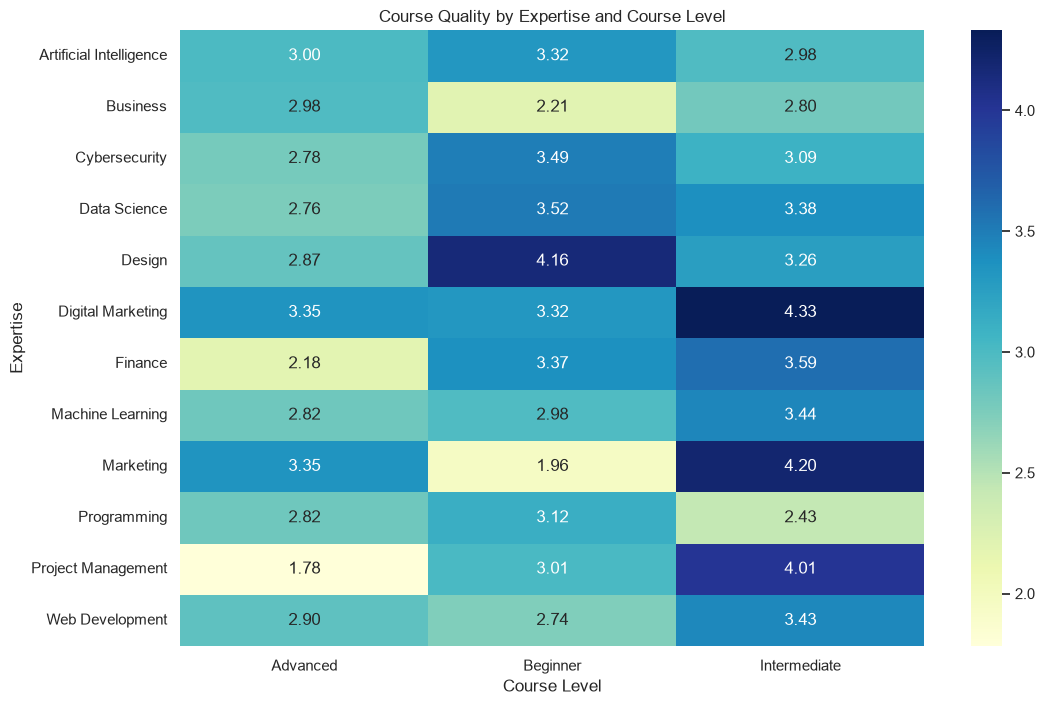

In [283]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    expertise_level,
    annot=True,
    fmt=".2f",
    cmap="YlGnBu"
)

plt.title(
    "Course Quality by Expertise and Course Level"
)

plt.xlabel(
    "Course Level"
)

plt.ylabel(
    "Expertise"
)

plt.show()

###  Instructor × Course Analysis

In [284]:
instructor_courses = (
    master_df
    .groupby(
        [
            "TeacherName",
            "CourseName",
            "CourseCategory",
            "CourseLevel"
        ]
    )
    .agg(
        TeacherRating=(
            "TeacherRating",
            "first"
        ),
        CourseRating=(
            "CourseRating",
            "first"
        ),
        Enrollments=(
            "TransactionID",
            "count"
        )
    )
    .reset_index()
)

display(
    instructor_courses.head(20)
)

,TeacherName,CourseName,CourseCategory,CourseLevel,TeacherRating,CourseRating,Enrollments
0,Aaron Kirby,Business Strategy,Business,Advanced,4.29,3.64,2
1,Aaron Kirby,Content Marketing,Marketing,Advanced,4.29,2.98,25
2,Aaron Kirby,Digital Marketing,Marketing,Intermediate,4.29,4.72,16
3,Aaron Kirby,Email Marketing,Marketing,Intermediate,4.29,4.11,23
4,Aaron Kirby,Entrepreneurship 101,Business,Intermediate,4.29,2.69,4
5,Aaron Kirby,Leadership Essentials,Business,Beginner,4.29,1.96,1
6,Aaron Kirby,SEO Mastery,Marketing,Advanced,4.29,4.79,26
7,Aaron Kirby,Sales Mastery,Business,Advanced,4.29,3.15,2
8,Aaron Kirby,Social Media Marketing,Marketing,Advanced,4.29,2.01,21
9,Adam Holmes,Business Strategy,Business,Advanced,3.99,3.64,1


### Find High-Enrollment Courses

In [285]:


popular_courses = instructor_courses.sort_values(
    "Enrollments",
    ascending=False
).head(20)

display(popular_courses)

,TeacherName,CourseName,CourseCategory,CourseLevel,TeacherRating,CourseRating,Enrollments
876,Yolanda Levine,Reinforcement Learning,Machine Learning,Intermediate,4.97,1.73,107
539,Kimberly Miller,Cyber Threat Intelligence,Cybersecurity,Beginner,4.58,4.94,103
861,Yolanda Levine,Intro to Machine Learning,Machine Learning,Intermediate,4.97,4.73,100
849,Yolanda Levine,Deep Learning,Machine Learning,Advanced,4.97,3.89,99
540,Kimberly Miller,Cybersecurity Fundamentals,Cybersecurity,Intermediate,4.58,3.93,97
548,Kimberly Miller,Ethical Hacking,Cybersecurity,Advanced,4.58,2.38,93
542,Kimberly Miller,Data Encryption,Cybersecurity,Intermediate,4.58,1.35,92
869,Yolanda Levine,Natural Language Processing,Machine Learning,Beginner,4.97,1.13,92
870,Yolanda Levine,Neural Networks,Machine Learning,Advanced,4.97,1.81,90
564,Kimberly Miller,Network Security,Cybersecurity,Intermediate,4.58,1.91,90


### Rating vs Enrollment

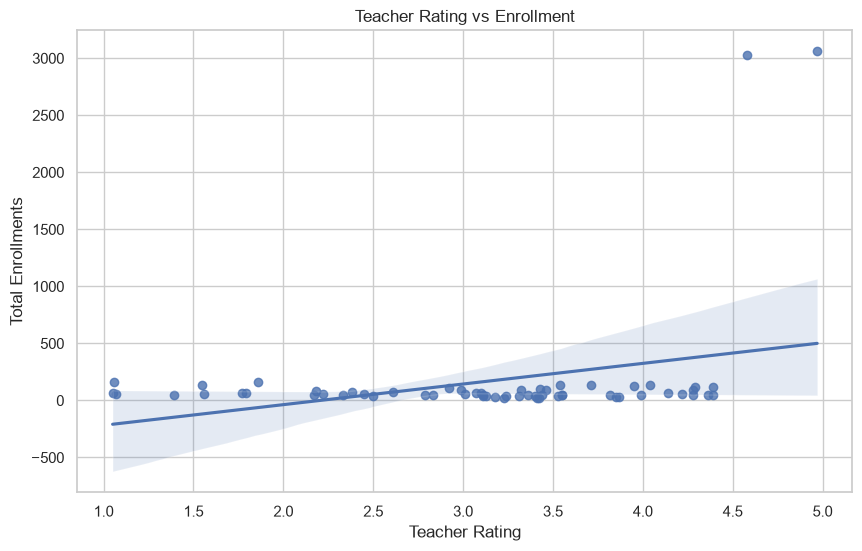

In [286]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=instructor_df,
    x="TeacherRating",
    y="TotalEnrollments"
)

plt.title(
    "Teacher Rating vs Enrollment"
)

plt.xlabel(
    "Teacher Rating"
)

plt.ylabel(
    "Total Enrollments"
)

plt.show()

In [287]:
rating_enrollment_corr = instructor_df[
    "TeacherRating"
].corr(
    instructor_df[
        "TotalEnrollments"
    ]
)

print(
    "Teacher Rating ↔ Enrollment:",
    round(
        rating_enrollment_corr,
        3
    )
)

Teacher Rating ↔ Enrollment: 0.318


### Course Rating vs Enrollment

In [288]:
course_enrollment_corr = instructor_courses[
    "CourseRating"
].corr(
    instructor_courses[
        "Enrollments"
    ]
)

print(
    "Course Rating ↔ Enrollment:",
    round(
        course_enrollment_corr,
        3
    )
)

Course Rating ↔ Enrollment: 0.005


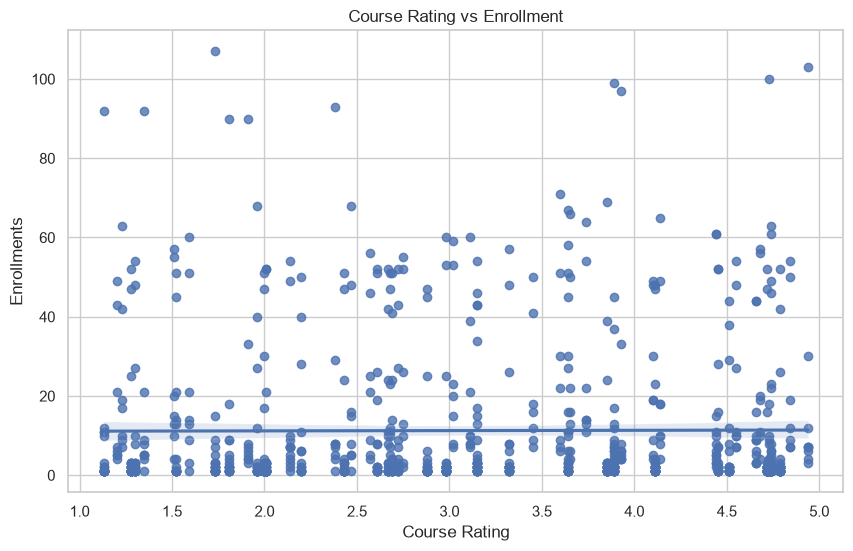

In [289]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=instructor_courses,
    x="CourseRating",
    y="Enrollments"
)

plt.title(
    "Course Rating vs Enrollment"
)

plt.xlabel(
    "Course Rating"
)

plt.ylabel(
    "Enrollments"
)

plt.show()

### Step 11 — Identify High Quality + High Demand Courses

In [290]:
high_quality_courses = instructor_courses[
    (
        instructor_courses["CourseRating"] >= 4
    ) &
    (
        instructor_courses["Enrollments"] >=
        instructor_courses["Enrollments"].median()
    )
]

display(
    high_quality_courses.sort_values(
        "Enrollments",
        ascending=False
    ).head(20)
)

,TeacherName,CourseName,CourseCategory,CourseLevel,TeacherRating,CourseRating,Enrollments
539,Kimberly Miller,Cyber Threat Intelligence,Cybersecurity,Beginner,4.58,4.94,103
861,Yolanda Levine,Intro to Machine Learning,Machine Learning,Intermediate,4.97,4.73,100
538,Kimberly Miller,Corporate Finance,Finance,Beginner,4.58,4.14,65
874,Yolanda Levine,Python Basics,Programming,Beginner,4.97,4.74,63
883,Yolanda Levine,Social Media Strategy,Digital Marketing,Beginner,4.97,4.44,61
576,Kimberly Miller,Social Media Strategy,Digital Marketing,Beginner,4.58,4.44,61
553,Kimberly Miller,Full-Stack Web Development,Web Development,Advanced,4.58,4.74,61
837,Yolanda Levine,Agile Project Management,Project Management,Beginner,4.97,4.68,57
530,Kimberly Miller,Agile Project Management,Project Management,Beginner,4.58,4.68,56
570,Kimberly Miller,Risk Management,Project Management,Intermediate,4.58,4.84,54


In [291]:
high_quality_courses = instructor_courses[
    (
        instructor_courses["CourseRating"] >= 4
    ) &
    (
        instructor_courses["Enrollments"] >=
        instructor_courses["Enrollments"].median()
    )
]

display(
    high_quality_courses.sort_values(
        "Enrollments",
        ascending=False
    ).head(20)
)

,TeacherName,CourseName,CourseCategory,CourseLevel,TeacherRating,CourseRating,Enrollments
539,Kimberly Miller,Cyber Threat Intelligence,Cybersecurity,Beginner,4.58,4.94,103
861,Yolanda Levine,Intro to Machine Learning,Machine Learning,Intermediate,4.97,4.73,100
538,Kimberly Miller,Corporate Finance,Finance,Beginner,4.58,4.14,65
874,Yolanda Levine,Python Basics,Programming,Beginner,4.97,4.74,63
883,Yolanda Levine,Social Media Strategy,Digital Marketing,Beginner,4.97,4.44,61
576,Kimberly Miller,Social Media Strategy,Digital Marketing,Beginner,4.58,4.44,61
553,Kimberly Miller,Full-Stack Web Development,Web Development,Advanced,4.58,4.74,61
837,Yolanda Levine,Agile Project Management,Project Management,Beginner,4.97,4.68,57
530,Kimberly Miller,Agile Project Management,Project Management,Beginner,4.58,4.68,56
570,Kimberly Miller,Risk Management,Project Management,Intermediate,4.58,4.84,54


### Identify Problem Courses

In [292]:
problem_courses = instructor_courses[
    (
        instructor_courses["CourseRating"] < 3
    ) &
    (
        instructor_courses["Enrollments"] >=
        instructor_courses["Enrollments"].median()
    )
]

display(
    problem_courses.sort_values(
        "Enrollments",
        ascending=False
    ).head(20)
)

,TeacherName,CourseName,CourseCategory,CourseLevel,TeacherRating,CourseRating,Enrollments
876,Yolanda Levine,Reinforcement Learning,Machine Learning,Intermediate,4.97,1.73,107
548,Kimberly Miller,Ethical Hacking,Cybersecurity,Advanced,4.58,2.38,93
542,Kimberly Miller,Data Encryption,Cybersecurity,Intermediate,4.58,1.35,92
869,Yolanda Levine,Natural Language Processing,Machine Learning,Beginner,4.97,1.13,92
564,Kimberly Miller,Network Security,Cybersecurity,Intermediate,4.58,1.91,90
870,Yolanda Levine,Neural Networks,Machine Learning,Advanced,4.97,1.81,90
550,Kimberly Miller,Financial Accounting,Finance,Beginner,4.58,2.47,68
865,Yolanda Levine,Leadership Essentials,Business,Beginner,4.97,1.96,68
873,Yolanda Levine,Project Planning,Project Management,Advanced,4.97,1.23,63
551,Kimberly Miller,Financial Modeling,Finance,Advanced,4.58,1.59,60


### Calculate Course Quality Score

In [293]:
course_quality = instructor_courses.copy()

course_quality["QualityScore"] = (
    course_quality["CourseRating"] / 5
) * 100

In [294]:
display(
    course_quality.sort_values(
        "QualityScore",
        ascending=False
    ).head(20)
)

,TeacherName,CourseName,CourseCategory,CourseLevel,TeacherRating,CourseRating,Enrollments,QualityScore
173,Brenda Mercer,Cyber Threat Intelligence,Cybersecurity,Beginner,1.86,4.94,30,98.8
187,Brent Walters,Cyber Threat Intelligence,Cybersecurity,Beginner,3.87,4.94,6,98.8
539,Kimberly Miller,Cyber Threat Intelligence,Cybersecurity,Beginner,4.58,4.94,103,98.8
625,Noah Stewart,Cyber Threat Intelligence,Cybersecurity,Beginner,3.82,4.94,12,98.8
603,Leonard Montgomery,Cyber Threat Intelligence,Cybersecurity,Beginner,3.24,4.94,3,98.8
652,Rebecca Webb,Cyber Threat Intelligence,Cybersecurity,Beginner,3.36,4.94,7,98.8
57,Alison Wilson,Cyber Threat Intelligence,Cybersecurity,Beginner,3.53,4.94,4,98.8
251,Christopher Nelson,Cyber Threat Intelligence,Cybersecurity,Beginner,3.85,4.94,7,98.8
392,James Holder,Cyber Threat Intelligence,Cybersecurity,Beginner,3.11,4.94,7,98.8
123,Benjamin Gray,Risk Management,Project Management,Intermediate,3.32,4.84,9,96.8


### Create Instructor Quality Categories

In [361]:
def quality_category(score):

    if score >= 80:
        return "Excellent"

    elif score >= 65:
        return "Good"

    elif score >= 50:
        return "Average"

    else:
        return "Needs Improvement"


instructor_df["QualityCategory"] = (
    instructor_df[
        "PerformanceScore"
    ].apply(quality_category)
)

In [362]:
display(
    instructor_df[
        "QualityCategory"
    ].value_counts()
)

QualityCategory
Needs Improvement    51
Average               7
Good                  1
Excellent             1
Name: count, dtype: int64

### Quality Category Visualization

Exception ignored in: <function ZipFile.__del__ at 0x0000022CDDC1F240>
Traceback (most recent call last):
  File "C:\Users\annu3\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 1988, in __del__
    self.close()
  File "C:\Users\annu3\AppData\Local\Programs\Python\Python313\Lib\zipfile\__init__.py", line 2005, in close
    self.fp.seek(self.start_dir)
ValueError: seek of closed file


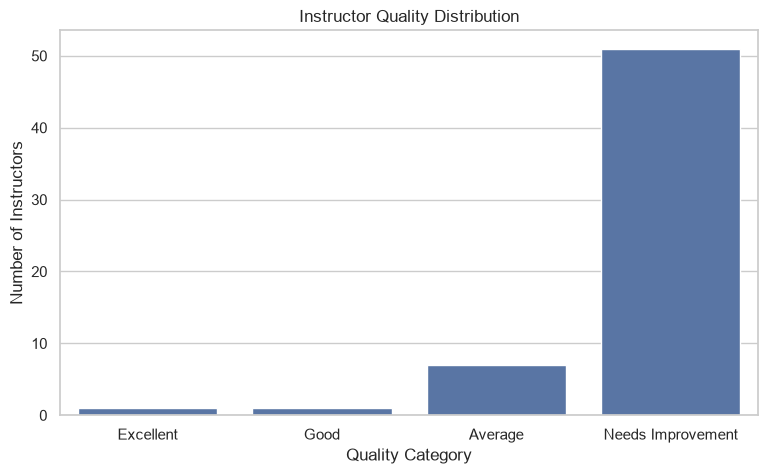

In [363]:
plt.figure(figsize=(9, 5))

sns.countplot(
    data=instructor_df,
    x="QualityCategory",
    order=[
        "Excellent",
        "Good",
        "Average",
        "Needs Improvement"
    ]
)

plt.title(
    "Instructor Quality Distribution"
)

plt.xlabel(
    "Quality Category"
)

plt.ylabel(
    "Number of Instructors"
)

plt.show()

### Statistical Significance

In [364]:
from scipy.stats import pearsonr

In [365]:
r, p = pearsonr(
    teachers["YearsOfExperience"].dropna(),
    teachers.loc[
        teachers["YearsOfExperience"].notna(),
        "TeacherRating"
    ]
)

print(
    "Correlation:",
    round(r, 3)
)

print(
    "P-value:",
    round(p, 5)
)

Correlation: 0.598
P-value: 0.0


In [366]:
if p < 0.05:
    print(
        "The relationship is statistically significant."
    )
else:
    print(
        "The relationship is not statistically significant."
    )

The relationship is statistically significant.


In [367]:
valid_corr = instructor_df[
    [
        "TeacherRating",
        "AverageCourseRating"
    ]
].dropna()

r, p = pearsonr(
    valid_corr["TeacherRating"],
    valid_corr["AverageCourseRating"]
)

print(
    "Correlation:",
    round(r, 3)
)

print(
    "P-value:",
    round(p, 5)
)

Correlation: 0.0
P-value: 0.9971


### Create Final KPI Dashboard Table

In [368]:
final_kpis = pd.DataFrame({
    "KPI": [
        "Average Teacher Rating",
        "Average Course Rating",
        "Experience Impact on Teacher Rating",
        "Experience Impact on Course Rating",
        "Teacher Rating vs Course Rating",
        "Teacher Rating vs Enrollment",
        "Total Instructors",
        "Total Courses",
        "Total Enrollments"
    ],

    "Value": [
        round(avg_teacher_rating, 2),
        round(avg_course_rating, 2),
        round(experience_teacher_corr, 3),
        round(experience_course_corr, 3),
        round(teacher_course_corr, 3),
        round(rating_enrollment_corr, 3),
        teachers["TeacherID"].nunique(),
        courses["CourseID"].nunique(),
        transactions["TransactionID"].nunique()
    ]
})

display(final_kpis)

,KPI,Value
0,Average Teacher Rating,3.120
1,Average Course Rating,3.100
2,Experience Impact on Teacher Rating,0.598
3,Experience Impact on Course Rating,-0.057
4,Teacher Rating vs Course Rating,0.000
5,Teacher Rating vs Enrollment,0.318
6,Total Instructors,60.000
7,Total Courses,60.000
8,Total Enrollments,10000.000


### Export all important results

In [369]:
with pd.ExcelWriter(
    "EduPro_Final_Analysis.xlsx",
    engine="openpyxl"
) as writer:

    teachers.to_excel(
        writer,
        sheet_name="Teachers",
        index=False
    )

    courses.to_excel(
        writer,
        sheet_name="Courses",
        index=False
    )

    master_df.to_excel(
        writer,
        sheet_name="Master_Data",
        index=False
    )

    instructor_df.to_excel(
        writer,
        sheet_name="Instructor_Analysis",
        index=False
    )

    expertise_analysis.to_excel(
        writer,
        sheet_name="Expertise_Analysis",
        index=False
    )

    category_analysis.to_excel(
        writer,
        sheet_name="Category_Analysis",
        index=False
    )

    level_analysis.to_excel(
        writer,
        sheet_name="Level_Analysis",
        index=False
    )

    experience_analysis.to_excel(
        writer,
        sheet_name="Experience_Analysis",
        index=False
    )

    final_kpis.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

print(
    "EduPro_Final_Analysis.xlsx created successfully!"
)

EduPro_Final_Analysis.xlsx created successfully!


### ML Model for Course Rating Prediction

In [370]:
ml_df = master_df[
    [
        "TeacherRating",
        "Age",
        "YearsOfExperience",
        "Gender",
        "Expertise",
        "CourseCategory",
        "CourseLevel",
        "CourseRating"
    ]
].copy()

ml_df = ml_df.dropna()

print("ML Dataset Shape:", ml_df.shape)

display(ml_df.head())

ML Dataset Shape: (10000, 8)


,TeacherRating,Age,YearsOfExperience,Gender,Expertise,CourseCategory,CourseLevel,CourseRating
0,4.58,49,24,Male,Cybersecurity,Marketing,Intermediate,4.72
1,4.58,49,24,Male,Cybersecurity,Project Management,Intermediate,3.45
2,4.58,49,24,Male,Cybersecurity,Marketing,Advanced,2.98
3,4.58,49,24,Male,Cybersecurity,Artificial Intelligence,Beginner,3.64
4,4.97,49,21,Female,Machine Learning,Digital Marketing,Beginner,2.14


### Separate Features and Target

In [371]:
X = ml_df[
    [
        "TeacherRating",
        "Age",
        "YearsOfExperience",
        "Gender",
        "Expertise",
        "CourseCategory",
        "CourseLevel"
    ]
]

y = ml_df["CourseRating"]

print("Features:")
display(X.head())

print("\nTarget:")
display(y.head())

Features:


,TeacherRating,Age,YearsOfExperience,Gender,Expertise,CourseCategory,CourseLevel
0,4.58,49,24,Male,Cybersecurity,Marketing,Intermediate
1,4.58,49,24,Male,Cybersecurity,Project Management,Intermediate
2,4.58,49,24,Male,Cybersecurity,Marketing,Advanced
3,4.58,49,24,Male,Cybersecurity,Artificial Intelligence,Beginner
4,4.97,49,21,Female,Machine Learning,Digital Marketing,Beginner



Target:


0    4.72
1    3.45
2    2.98
3    3.64
4    2.14
Name: CourseRating, dtype: float64

### Train/Test Split

In [372]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8000, 7)
Testing Data: (2000, 7)


### Identify Numeric & Categorical Features

In [373]:
numeric_features = [
    "TeacherRating",
    "Age",
    "YearsOfExperience"
]

categorical_features = [
    "Gender",
    "Expertise",
    "CourseCategory",
    "CourseLevel"
]

### Preprocessing

In [374]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            "passthrough",
            numeric_features
        ),

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

### Linear Regression

In [375]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            LinearRegression()
        )
    ]
)

linear_model.fit(
    X_train,
    y_train
)

linear_pred = linear_model.predict(
    X_test
)

### Evaluate Linear Regression

In [376]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

linear_mae = mean_absolute_error(
    y_test,
    linear_pred
)

linear_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        linear_pred
    )
)

linear_r2 = r2_score(
    y_test,
    linear_pred
)

print("Linear Regression")
print("-------------------------")
print("MAE :", round(linear_mae, 4))
print("RMSE:", round(linear_rmse, 4))
print("R²  :", round(linear_r2, 4))

Linear Regression
-------------------------
MAE : 0.8975
RMSE: 1.078
R²  : 0.1276


### Random Forest

In [377]:
from sklearn.ensemble import RandomForestRegressor

random_forest = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                max_depth=10,
                random_state=42
            )
        )
    ]
)

random_forest.fit(
    X_train,
    y_train
)

rf_pred = random_forest.predict(
    X_test
)

### Random Forest Evaluation

In [378]:
rf_mae = mean_absolute_error(
    y_test,
    rf_pred
)

rf_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        rf_pred
    )
)

rf_r2 = r2_score(
    y_test,
    rf_pred
)

print("Random Forest")
print("-------------------------")
print("MAE :", round(rf_mae, 4))
print("RMSE:", round(rf_rmse, 4))
print("R²  :", round(rf_r2, 4))

Random Forest
-------------------------
MAE : 0.6999
RMSE: 0.9218
R²  : 0.362


### Gradient Boosting

In [379]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_model = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),

        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gradient_model.fit(
    X_train,
    y_train
)

gb_pred = gradient_model.predict(
    X_test
)

### gradient boosting

In [380]:
gb_mae = mean_absolute_error(
    y_test,
    gb_pred
)

gb_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        gb_pred
    )
)

gb_r2 = r2_score(
    y_test,
    gb_pred
)

print("Gradient Boosting")
print("-------------------------")
print("MAE :", round(gb_mae, 4))
print("RMSE:", round(gb_rmse, 4))
print("R²  :", round(gb_r2, 4))

Gradient Boosting
-------------------------
MAE : 0.7302
RMSE: 0.924
R²  : 0.3589


### Compare All Models

In [381]:
model_comparison = pd.DataFrame({

    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],

    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],

    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

display(
    model_comparison.round(4)
)

,Model,MAE,RMSE,R2
0,Linear Regression,0.8975,1.0780,0.1276
1,Random Forest,0.6999,0.9218,0.3620
2,Gradient Boosting,0.7302,0.9240,0.3589


### Visual Model Comparison

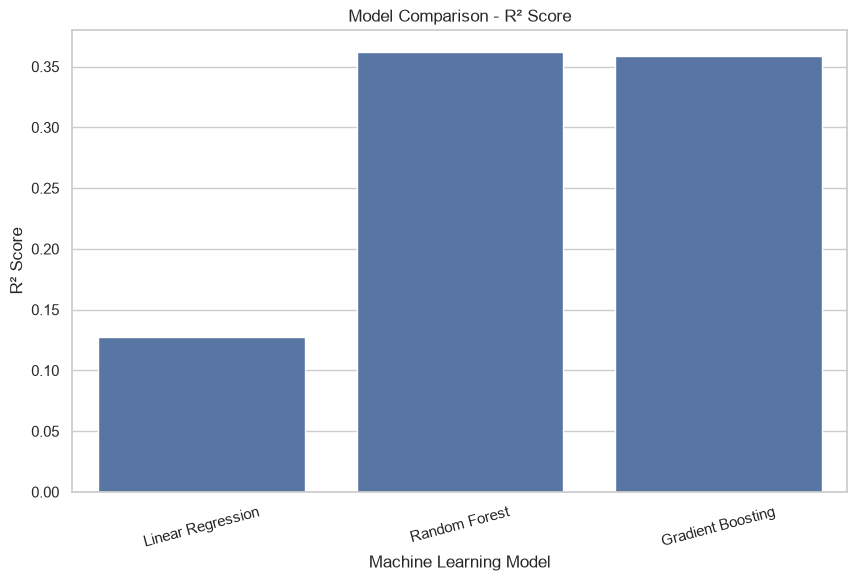

In [382]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="R2"
)

plt.title(
    "Model Comparison - R² Score"
)

plt.xlabel("Machine Learning Model")
plt.ylabel("R² Score")

plt.xticks(rotation=15)

plt.show()

### Find Best Model

In [383]:
best_model_row = model_comparison.sort_values(
    by="R2",
    ascending=False
).iloc[0]

print(
    "Best Model:",
    best_model_row["Model"]
)

print(
    "R² Score:",
    round(
        best_model_row["R2"],
        4
    )
)

print(
    "RMSE:",
    round(
        best_model_row["RMSE"],
        4
    )
)

Best Model: Random Forest
R² Score: 0.362
RMSE: 0.9218


### Actual vs Predicted

In [384]:
best_predictions = rf_pred

In [385]:
prediction_df = pd.DataFrame({

    "Actual": y_test.values,

    "Predicted": best_predictions

})

display(
    prediction_df.head(20)
)

,Actual,Predicted
0,4.72,4.431091
1,2.98,3.296507
2,2.01,3.152581
3,1.91,2.504247
4,3.89,3.192194
5,3.60,3.253636
6,1.28,3.222768
7,4.66,4.557174
8,3.11,3.065542
9,1.35,2.507808


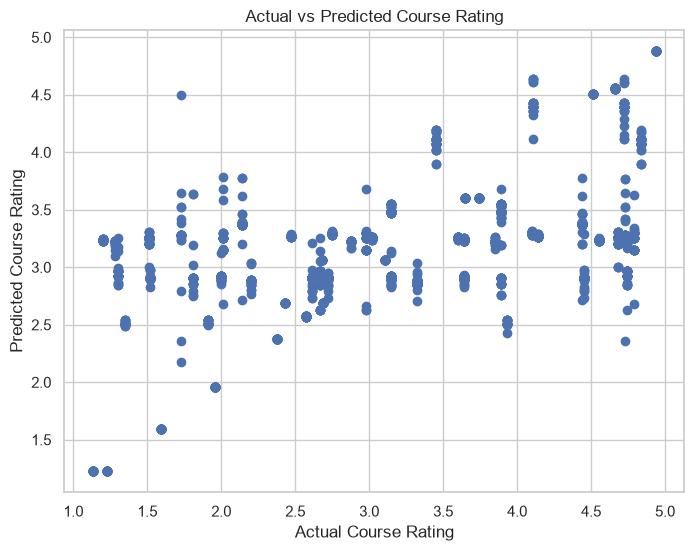

In [386]:
plt.figure(figsize=(8, 6))

plt.scatter(
    prediction_df["Actual"],
    prediction_df["Predicted"]
)

plt.xlabel(
    "Actual Course Rating"
)

plt.ylabel(
    "Predicted Course Rating"
)

plt.title(
    "Actual vs Predicted Course Rating"
)

plt.show()

### Prediction Error

In [387]:
prediction_df["Error"] = (
    prediction_df["Actual"]
    -
    prediction_df["Predicted"]
)

display(
    prediction_df.head(20)
)

,Actual,Predicted,Error
0,4.72,4.431091,2.889093e-01
1,2.98,3.296507,-3.165069e-01
2,2.01,3.152581,-1.142581e+00
3,1.91,2.504247,-5.942472e-01
4,3.89,3.192194,6.978058e-01
5,3.60,3.253636,3.463640e-01
6,1.28,3.222768,-1.942768e+00
7,4.66,4.557174,1.028263e-01
8,3.11,3.065542,4.445762e-02
9,1.35,2.507808,-1.157808e+00


### Error Distribution

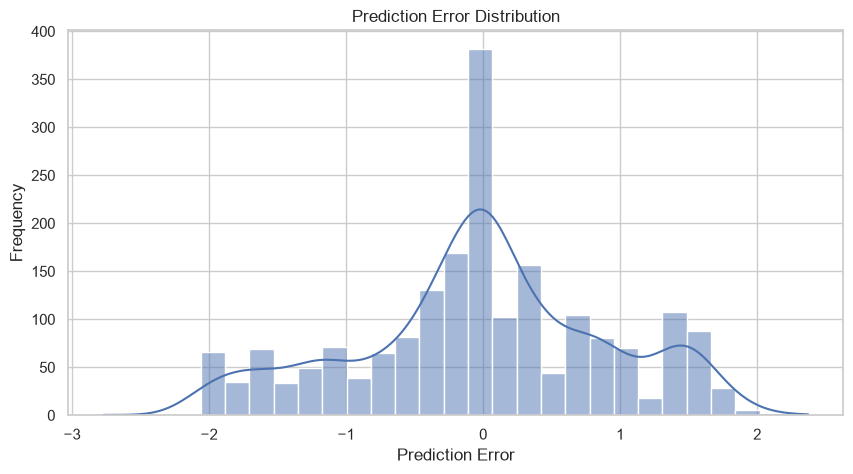

In [388]:
plt.figure(figsize=(10, 5))

sns.histplot(
    prediction_df["Error"],
    kde=True
)

plt.title(
    "Prediction Error Distribution"
)

plt.xlabel(
    "Prediction Error"
)

plt.ylabel(
    "Frequency"
)

plt.show()

### Feature Importance

In [389]:
rf_preprocessor = random_forest.named_steps[
    "preprocessor"
]

rf_estimator = random_forest.named_steps[
    "model"
]

In [390]:
feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

feature_importance = pd.DataFrame({

    "Feature": feature_names,

    "Importance":
        rf_estimator.feature_importances_

})

feature_importance = (
    feature_importance
    .sort_values(
        "Importance",
        ascending=False
    )
)

display(
    feature_importance.head(20)
)

,Feature,Importance
27,categorical__CourseCategory_Project Management,0.131015
31,categorical__CourseLevel_Intermediate,0.119821
19,categorical__CourseCategory_Cybersecurity,0.116774
29,categorical__CourseLevel_Advanced,0.103749
25,categorical__CourseCategory_Marketing,0.096413
30,categorical__CourseLevel_Beginner,0.075311
23,categorical__CourseCategory_Finance,0.065864
18,categorical__CourseCategory_Business,0.056684
21,categorical__CourseCategory_Design,0.051047
24,categorical__CourseCategory_Machine Learning,0.046704


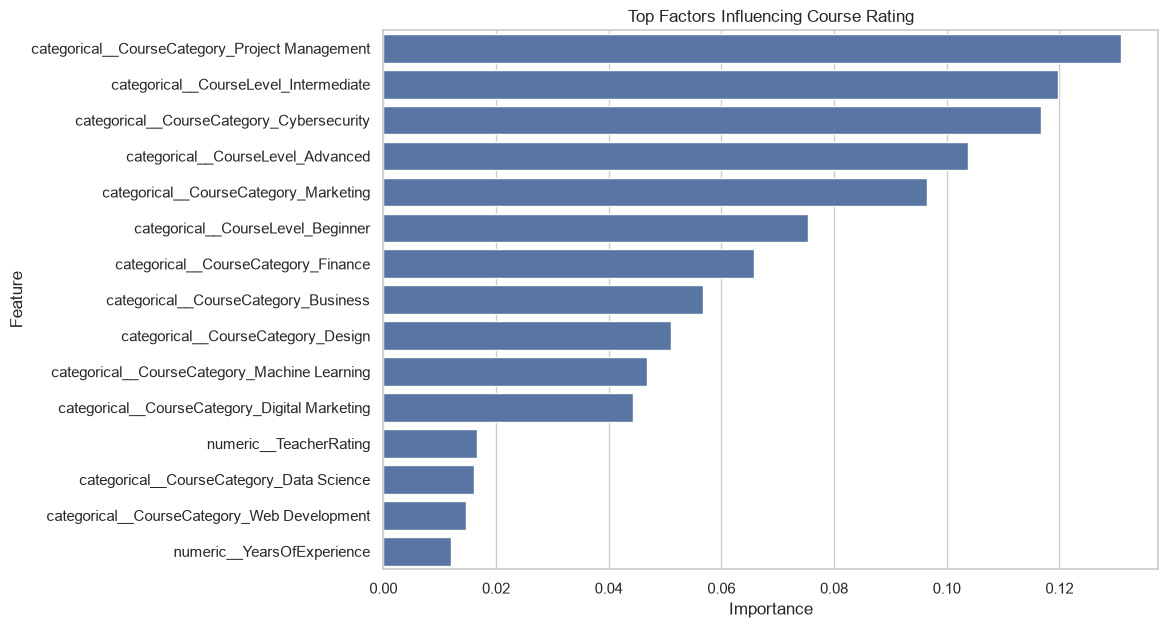

In [391]:
top_features = feature_importance.head(15)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_features,
    x="Importance",
    y="Feature"
)

plt.title(
    "Top Factors Influencing Course Rating"
)

plt.xlabel("Importance")
plt.ylabel("Feature")

plt.show()

### Build Prediction Function

In [392]:
def predict_course_rating(
    teacher_rating,
    age,
    experience,
    gender,
    expertise,
    category,
    level
):

    new_data = pd.DataFrame({

        "TeacherRating": [teacher_rating],

        "Age": [age],

        "YearsOfExperience": [experience],

        "Gender": [gender],

        "Expertise": [expertise],

        "CourseCategory": [category],

        "CourseLevel": [level]
    })

    prediction = random_forest.predict(
        new_data
    )[0]

    prediction = np.clip(
        prediction,
        1,
        5
    )

    return prediction

### Test Prediction

In [393]:
predicted_rating = predict_course_rating(
    teacher_rating=4.5,
    age=35,
    experience=8,
    gender="Male",
    expertise="Marketing",
    category="Marketing",
    level="Intermediate"
)

print(
    "Predicted Course Rating:",
    round(
        predicted_rating,
        2
    ),
    "/ 5"
)

Predicted Course Rating: 4.36 / 5


### Course Quality Classification

In [394]:
def classify_course_quality(rating):

    if rating >= 4.5:
        return "Excellent"

    elif rating >= 4.0:
        return "Good"

    elif rating >= 3.0:
        return "Average"

    else:
        return "Needs Improvement"

In [395]:
quality = classify_course_quality(
    predicted_rating
)

print(
    "Predicted Quality:",
    quality
)

Predicted Quality: Good


### Complete Prediction Result

In [396]:
print("=" * 50)

print(
    "        EDUPRO COURSE PREDICTION"
)

print("=" * 50)

print(
    "Teacher Rating:",
    4.5
)

print(
    "Experience:",
    8,
    "years"
)

print(
    "Expertise:",
    "Marketing"
)

print(
    "Category:",
    "Marketing"
)

print(
    "Level:",
    "Intermediate"
)

print(
    "\nPredicted Course Rating:",
    round(
        predicted_rating,
        2
    ),
    "/ 5"
)

print(
    "Course Quality:",
    quality
)

print("=" * 50)

        EDUPRO COURSE PREDICTION
Teacher Rating: 4.5
Experience: 8 years
Expertise: Marketing
Category: Marketing
Level: Intermediate

Predicted Course Rating: 4.36 / 5
Course Quality: Good


### Save ML Model

In [397]:
import joblib

joblib.dump(
    random_forest,
    "EduPro_Course_Rating_Model.pkl"
)

print(
    "✅ Model saved successfully!"
)

✅ Model saved successfully!


### Save Feature Importance

In [398]:
feature_importance.to_csv(
    "EduPro_Feature_Importance.csv",
    index=False
)

print(
    "✅ Feature importance saved!"
)

✅ Feature importance saved!


### Save Model Results

In [399]:
model_comparison.to_csv(
    "EduPro_Model_Comparison.csv",
    index=False
)

print(
    "✅ Model comparison saved!"
)

✅ Model comparison saved!


In [400]:
top_instructor = instructor_df.sort_values(
    "PerformanceScore",
    ascending=False
).iloc[0]

print("TOP PERFORMING INSTRUCTOR")
print("-" * 40)

print("Name:", top_instructor["TeacherName"])
print("Expertise:", top_instructor["Expertise"])
print("Experience:", top_instructor["YearsOfExperience"])
print("Teacher Rating:", round(top_instructor["TeacherRating"], 2))
print(
    "Course Rating:",
    round(top_instructor["AverageCourseRating"], 2)
)
print(
    "Performance Score:",
    round(top_instructor["PerformanceScore"], 2)
)

TOP PERFORMING INSTRUCTOR
----------------------------------------
Name: Yolanda Levine
Expertise: Machine Learning
Experience: 21
Teacher Rating: 4.97
Course Rating: 3.08
Performance Score: 81.26


In [401]:
best_expertise = (
    instructor_df
    .groupby("Expertise")
    .agg(
        AverageTeacherRating=("TeacherRating", "mean"),
        AverageCourseRating=("AverageCourseRating", "mean"),
        AverageEnrollment=("TotalEnrollments", "mean"),
        InstructorCount=("TeacherID", "nunique")
    )
    .reset_index()
    .sort_values(
        "AverageCourseRating",
        ascending=False
    )
)

print("TOP EXPERTISE AREAS")
print("-" * 40)

display(
    best_expertise.head(10).round(2)
)

TOP EXPERTISE AREAS
----------------------------------------


,Expertise,AverageTeacherRating,AverageCourseRating,AverageEnrollment,InstructorCount
8,Marketing,4.29,3.65,120.00,1
5,Digital Marketing,3.05,3.55,43.55,11
3,Data Science,3.03,3.28,86.40,5
6,Finance,3.26,3.17,68.33,6
4,Design,2.29,3.16,81.00,4
0,Artificial Intelligence,3.17,3.16,64.83,6
10,Project Management,2.66,3.08,73.60,5
2,Cybersecurity,3.47,3.04,383.33,9
9,Programming,3.95,2.98,123.00,1
11,Web Development,2.51,2.94,68.80,5


In [402]:
best_categories = (
    master_df
    .groupby("CourseCategory")
    .agg(
        AverageRating=("CourseRating", "mean"),
        TotalEnrollments=("TransactionID", "count"),
        CourseCount=("CourseID", "nunique")
    )
    .reset_index()
    .sort_values(
        "AverageRating",
        ascending=False
    )
)

print("TOP COURSE CATEGORIES")

display(
    best_categories.head(10).round(2)
)

TOP COURSE CATEGORIES


,CourseCategory,AverageRating,TotalEnrollments,CourseCount
8,Marketing,3.69,806,5
5,Digital Marketing,3.68,808,5
3,Data Science,3.34,916,5
4,Design,3.18,827,5
10,Project Management,3.12,829,5
0,Artificial Intelligence,3.12,829,5
9,Programming,3.05,806,5
6,Finance,3.04,864,5
2,Cybersecurity,2.98,819,5
11,Web Development,2.88,844,5


In [403]:
best_levels = (
    master_df
    .groupby("CourseLevel")
    .agg(
        AverageRating=("CourseRating", "mean"),
        TotalEnrollments=("TransactionID", "count"),
        CourseCount=("CourseID", "nunique")
    )
    .reset_index()
    .sort_values(
        "AverageRating",
        ascending=False
    )
)

print("COURSE LEVEL PERFORMANCE")

display(
    best_levels.round(2)
)

COURSE LEVEL PERFORMANCE


,CourseLevel,AverageRating,TotalEnrollments,CourseCount
2,Intermediate,3.34,2952,18
1,Beginner,3.24,3573,21
0,Advanced,2.82,3475,21


In [404]:
course_performance = (
    master_df
    .groupby(
        [
            "CourseID",
            "CourseName",
            "CourseCategory",
            "CourseLevel"
        ]
    )
    .agg(
        CourseRating=("CourseRating", "first"),
        Enrollment=("TransactionID", "count")
    )
    .reset_index()
)

median_enrollment = course_performance[
    "Enrollment"
].median()

priority_courses = course_performance[
    (course_performance["CourseRating"] < 3) &
    (course_performance["Enrollment"] >= median_enrollment)
].sort_values(
    "Enrollment",
    ascending=False
)

print("⚠️ COURSES REQUIRING PRIORITY IMPROVEMENT")

display(
    priority_courses.head(20)
)

⚠️ COURSES REQUIRING PRIORITY IMPROVEMENT


,CourseID,CourseName,CourseCategory,CourseLevel,CourseRating,Enrollment
6,CR00007,UI/UX Design,Design,Advanced,2.61,178
18,CR00019,Content Marketing,Marketing,Advanced,2.98,177
39,CR00040,Leadership in Projects,Project Management,Beginner,1.51,174
44,CR00045,Financial Modeling,Finance,Advanced,1.59,172
50,CR00051,HTML & CSS,Web Development,Advanced,1.30,171
12,CR00013,Finance for Startups,Business,Advanced,2.00,170
29,CR00030,Reinforcement Learning,Machine Learning,Intermediate,1.73,169
14,CR00015,Leadership Essentials,Business,Beginner,1.96,168
38,CR00039,Project Planning,Project Management,Advanced,1.23,167
4,CR00005,Full Stack Development,Programming,Beginner,1.28,166


In [405]:
high_quality_courses = course_performance[
    (course_performance["CourseRating"] >= 4)
]

high_quality_courses = high_quality_courses.sort_values(
    ["CourseRating", "Enrollment"],
    ascending=[False, False]
)

print("🏆 HIGH QUALITY COURSES")

display(
    high_quality_courses.head(20)
)

🏆 HIGH QUALITY COURSES


,CourseID,CourseName,CourseCategory,CourseLevel,CourseRating,Enrollment
34,CR00035,Cyber Threat Intelligence,Cybersecurity,Beginner,4.94,179
37,CR00038,Risk Management,Project Management,Intermediate,4.84,158
16,CR00017,SEO Mastery,Marketing,Advanced,4.79,158
54,CR00055,Full-Stack Web Development,Web Development,Advanced,4.74,178
0,CR00001,Python Basics,Programming,Beginner,4.74,164
25,CR00026,Intro to Machine Learning,Machine Learning,Intermediate,4.73,172
15,CR00016,Digital Marketing,Marketing,Intermediate,4.72,153
35,CR00036,Agile Project Management,Project Management,Beginner,4.68,177
58,CR00059,Affiliate Marketing,Digital Marketing,Intermediate,4.66,161
49,CR00050,Computer Vision,Artificial Intelligence,Beginner,4.55,174


In [406]:
instructor_df["PerformanceTier"] = pd.cut(
    instructor_df["PerformanceScore"],
    bins=[
        -np.inf,
        50,
        70,
        np.inf
    ],
    labels=[
        "Low Performer",
        "Medium Performer",
        "High Performer"
    ]
)

tier_analysis = (
    instructor_df
    .groupby(
        "PerformanceTier",
        observed=True
    )
    .agg(
        InstructorCount=("TeacherID", "count"),
        AverageTeacherRating=("TeacherRating", "mean"),
        AverageCourseRating=("AverageCourseRating", "mean"),
        AverageEnrollment=("TotalEnrollments", "mean")
    )
    .reset_index()
)

display(
    tier_analysis.round(2)
)

,PerformanceTier,InstructorCount,AverageTeacherRating,AverageCourseRating,AverageEnrollment
0,Low Performer,51,2.95,3.10,66.20
1,Medium Performer,7,3.90,3.58,76.86
2,High Performer,2,4.78,3.11,3043.00


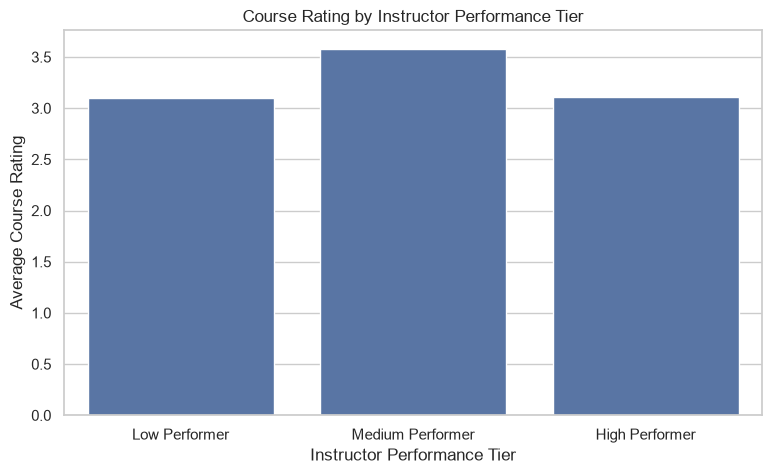

In [407]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=tier_analysis,
    x="PerformanceTier",
    y="AverageCourseRating"
)

plt.title(
    "Course Rating by Instructor Performance Tier"
)

plt.xlabel(
    "Instructor Performance Tier"
)

plt.ylabel(
    "Average Course Rating"
)

plt.show()

In [408]:
enrollment_influence = instructor_df[
    [
        "TeacherRating",
        "TotalEnrollments",
        "PerformanceScore"
    ]
].corr()

display(
    enrollment_influence.round(3)
)

,TeacherRating,TotalEnrollments,PerformanceScore
TeacherRating,1.000,0.318,0.844
TotalEnrollments,0.318,1.000,0.540
PerformanceScore,0.844,0.540,1.000


In [409]:
teacher_enrollment_corr = instructor_df[
    "TeacherRating"
].corr(
    instructor_df[
        "TotalEnrollments"
    ]
)

performance_enrollment_corr = instructor_df[
    "PerformanceScore"
].corr(
    instructor_df[
        "TotalEnrollments"
    ]
)

print(
    "Teacher Rating ↔ Enrollment:",
    round(teacher_enrollment_corr, 3)
)

print(
    "Performance Score ↔ Enrollment:",
    round(performance_enrollment_corr, 3)
)

Teacher Rating ↔ Enrollment: 0.318
Performance Score ↔ Enrollment: 0.54


In [415]:
from scipy.stats import pearsonr

In [416]:
# Experience vs Teacher Rating
data1 = instructor_df[
    ["YearsOfExperience", "TeacherRating"]
].dropna()

r_experience_teacher, p1 = pearsonr(
    data1["YearsOfExperience"],
    data1["TeacherRating"]
)


# Experience vs Course Rating
data2 = instructor_df[
    ["YearsOfExperience", "AverageCourseRating"]
].dropna()

r_experience_course, p2 = pearsonr(
    data2["YearsOfExperience"],
    data2["AverageCourseRating"]
)


# Teacher Rating vs Course Rating
data3 = instructor_df[
    ["TeacherRating", "AverageCourseRating"]
].dropna()

r_teacher_course, p3 = pearsonr(
    data3["TeacherRating"],
    data3["AverageCourseRating"]
)


print("Experience ↔ Teacher Rating:",
      round(r_experience_teacher, 3))

print("Experience ↔ Course Rating:",
      round(r_experience_course, 3))

print("Teacher Rating ↔ Course Rating:",
      round(r_teacher_course, 3))

Experience ↔ Teacher Rating: 0.598
Experience ↔ Course Rating: -0.057
Teacher Rating ↔ Course Rating: 0.0


In [417]:
teacher_enrollment_corr = instructor_df[
    "TeacherRating"
].corr(
    instructor_df["TotalEnrollments"]
)

performance_enrollment_corr = instructor_df[
    "PerformanceScore"
].corr(
    instructor_df["TotalEnrollments"]
)

print(
    "Teacher Rating ↔ Enrollment:",
    round(teacher_enrollment_corr, 3)
)

print(
    "Performance Score ↔ Enrollment:",
    round(performance_enrollment_corr, 3)
)

Teacher Rating ↔ Enrollment: 0.318
Performance Score ↔ Enrollment: 0.54


In [418]:
final_dashboard_kpis = pd.DataFrame({
    "KPI": [
        "Total Instructors",
        "Total Courses",
        "Total Enrollments",
        "Average Teacher Rating",
        "Average Course Rating",
        "Experience → Teacher Rating",
        "Experience → Course Rating",
        "Teacher Rating → Course Rating",
        "Teacher Rating → Enrollment",
        "Performance Score → Enrollment"
    ],

    "Value": [
        teachers["TeacherID"].nunique(),

        courses["CourseID"].nunique(),

        transactions["TransactionID"].nunique(),

        round(
            teachers["TeacherRating"].mean(),
            2
        ),

        round(
            courses["CourseRating"].mean(),
            2
        ),

        round(r, 3),

        round(
            r_experience_course,
            3
        ),

        round(
            r_teacher_course,
            3
        ),

        round(
            teacher_enrollment_corr,
            3
        ),

        round(
            performance_enrollment_corr,
            3
        )
    ]
})

display(
    final_dashboard_kpis
)

,KPI,Value
0,Total Instructors,60.000
1,Total Courses,60.000
2,Total Enrollments,10000.000
3,Average Teacher Rating,3.120
4,Average Course Rating,3.100
5,Experience → Teacher Rating,0.000
6,Experience → Course Rating,-0.057
7,Teacher Rating → Course Rating,0.000
8,Teacher Rating → Enrollment,0.318
9,Performance Score → Enrollment,0.540


In [419]:
with pd.ExcelWriter(
    "EduPro_Final_Report.xlsx",
    engine="openpyxl"
) as writer:

    final_dashboard_kpis.to_excel(
        writer,
        sheet_name="KPIs",
        index=False
    )

    instructor_df.to_excel(
        writer,
        sheet_name="Instructors",
        index=False
    )

    course_performance.to_excel(
        writer,
        sheet_name="Courses",
        index=False
    )

    best_expertise.to_excel(
        writer,
        sheet_name="Expertise",
        index=False
    )

    best_categories.to_excel(
        writer,
        sheet_name="Categories",
        index=False
    )

    best_levels.to_excel(
        writer,
        sheet_name="Levels",
        index=False
    )

    tier_analysis.to_excel(
        writer,
        sheet_name="Performance_Tiers",
        index=False
    )

    priority_courses.to_excel(
        writer,
        sheet_name="Priority_Courses",
        index=False
    )

    high_quality_courses.to_excel(
        writer,
        sheet_name="High_Quality_Courses",
        index=False
    )

print("✅ EduPro_Final_Report.xlsx created!")

✅ EduPro_Final_Report.xlsx created!


In [420]:
print("=" * 70)
print("              EDUPRO PROJECT FINDINGS")
print("=" * 70)

print("\n📌 1. INSTRUCTOR PERFORMANCE")
print(
    f"Top Instructor: {top_instructor['TeacherName']}"
)
print(
    f"Performance Score: {top_instructor['PerformanceScore']:.2f}"
)

print("\n📌 2. BEST EXPERTISE")
print(
    f"Highest-rated Expertise: "
    f"{best_expertise.iloc[0]['Expertise']}"
)
print(
    f"Average Course Rating: "
    f"{best_expertise.iloc[0]['AverageCourseRating']:.2f}"
)

print("\n📌 3. BEST COURSE CATEGORY")
print(
    f"Category: "
    f"{best_categories.iloc[0]['CourseCategory']}"
)
print(
    f"Average Rating: "
    f"{best_categories.iloc[0]['AverageRating']:.2f}"
)

print("\n📌 4. BEST COURSE LEVEL")
print(
    f"Level: "
    f"{best_levels.iloc[0]['CourseLevel']}"
)
print(
    f"Average Rating: "
    f"{best_levels.iloc[0]['AverageRating']:.2f}"
)

print("\n📌 5. EXPERIENCE IMPACT")
print(
    f"Experience → Teacher Rating: {r:.3f}"
)
print(
    f"Experience → Course Rating: "
    f"{r_experience_course:.3f}"
)

print("\n📌 6. INSTRUCTOR IMPACT")
print(
    f"Teacher Rating → Course Rating: "
    f"{r_teacher_course:.3f}"
)

print("\n📌 7. ENROLLMENT INFLUENCE")
print(
    f"Teacher Rating → Enrollment: "
    f"{teacher_enrollment_corr:.3f}"
)

print(
    f"Performance Score → Enrollment: "
    f"{performance_enrollment_corr:.3f}"
)

print("\n📌 8. PRIORITY IMPROVEMENT COURSES")
print(
    f"Courses requiring attention: "
    f"{len(priority_courses)}"
)

print("\n" + "=" * 70)

              EDUPRO PROJECT FINDINGS

📌 1. INSTRUCTOR PERFORMANCE
Top Instructor: Yolanda Levine
Performance Score: 81.26

📌 2. BEST EXPERTISE
Highest-rated Expertise: Marketing
Average Course Rating: 3.65

📌 3. BEST COURSE CATEGORY
Category: Marketing
Average Rating: 3.69

📌 4. BEST COURSE LEVEL
Level: Intermediate
Average Rating: 3.34

📌 5. EXPERIENCE IMPACT
Experience → Teacher Rating: 0.000
Experience → Course Rating: -0.057

📌 6. INSTRUCTOR IMPACT
Teacher Rating → Course Rating: 0.000

📌 7. ENROLLMENT INFLUENCE
Teacher Rating → Enrollment: 0.318
Performance Score → Enrollment: 0.540

📌 8. PRIORITY IMPROVEMENT COURSES
Courses requiring attention: 13



### Create Final Findings Table

In [421]:
import pandas as pd
import numpy as np

# =========================================================
# FINAL CORRELATIONS
# =========================================================

r_experience_teacher = (
    instructor_df["YearsOfExperience"]
    .corr(instructor_df["TeacherRating"])
)

r_experience_course = (
    instructor_df["YearsOfExperience"]
    .corr(instructor_df["AverageCourseRating"])
)

r_teacher_course = (
    instructor_df["TeacherRating"]
    .corr(instructor_df["AverageCourseRating"])
)

r_teacher_enrollment = (
    instructor_df["TeacherRating"]
    .corr(instructor_df["TotalEnrollments"])
)

r_performance_enrollment = (
    instructor_df["PerformanceScore"]
    .corr(instructor_df["TotalEnrollments"])
)


# =========================================================
# BASIC KPIs
# =========================================================

total_instructors = instructor_df["TeacherID"].nunique()

total_courses = master_df["CourseID"].nunique()

total_enrollments = master_df["TransactionID"].nunique()

avg_teacher_rating = instructor_df[
    "TeacherRating"
].mean()

avg_course_rating = master_df[
    "CourseRating"
].mean()


# =========================================================
# BEST EXPERTISE
# =========================================================

expertise_analysis = (
    master_df
    .groupby("Expertise")
    .agg(
        AverageCourseRating=("CourseRating", "mean"),
        CourseCount=("CourseID", "nunique"),
        Enrollments=("TransactionID", "count")
    )
    .reset_index()
    .sort_values(
        "AverageCourseRating",
        ascending=False
    )
)

best_expertise = expertise_analysis.iloc[0]


# =========================================================
# BEST CATEGORY
# =========================================================

category_analysis = (
    master_df
    .groupby("CourseCategory")
    .agg(
        AverageRating=("CourseRating", "mean"),
        CourseCount=("CourseID", "nunique"),
        Enrollments=("TransactionID", "count")
    )
    .reset_index()
    .sort_values(
        "AverageRating",
        ascending=False
    )
)

best_category = category_analysis.iloc[0]


# =========================================================
# BEST LEVEL
# =========================================================

level_analysis = (
    master_df
    .groupby("CourseLevel")
    .agg(
        AverageRating=("CourseRating", "mean"),
        CourseCount=("CourseID", "nunique"),
        Enrollments=("TransactionID", "count")
    )
    .reset_index()
    .sort_values(
        "AverageRating",
        ascending=False
    )
)

best_level = level_analysis.iloc[0]


# =========================================================
# TOP INSTRUCTOR
# =========================================================

top_instructor = (
    instructor_df
    .sort_values(
        "PerformanceScore",
        ascending=False
    )
    .iloc[0]
)


# =========================================================
# FINAL KPI TABLE
# =========================================================

final_kpis = pd.DataFrame({

    "KPI": [

        "Total Instructors",
        "Total Courses",
        "Total Enrollments",

        "Average Teacher Rating",
        "Average Course Rating",

        "Best Expertise",
        "Best Expertise Course Rating",

        "Best Course Category",
        "Best Category Rating",

        "Best Course Level",
        "Best Level Rating",

        "Experience → Teacher Rating",
        "Experience → Course Rating",

        "Teacher Rating → Course Rating",

        "Teacher Rating → Enrollment",
        "Performance Score → Enrollment",

        "Top Instructor",
        "Top Instructor Performance Score"
    ],

    "Value": [

        total_instructors,
        total_courses,
        total_enrollments,

        round(avg_teacher_rating, 2),
        round(avg_course_rating, 2),

        best_expertise["Expertise"],
        round(
            best_expertise["AverageCourseRating"],
            2
        ),

        best_category["CourseCategory"],
        round(
            best_category["AverageRating"],
            2
        ),

        best_level["CourseLevel"],
        round(
            best_level["AverageRating"],
            2
        ),

        round(r_experience_teacher, 3),
        round(r_experience_course, 3),

        round(r_teacher_course, 3),

        round(r_teacher_enrollment, 3),
        round(r_performance_enrollment, 3),

        top_instructor["TeacherName"],
        round(
            top_instructor["PerformanceScore"],
            2
        )
    ]
})


display(final_kpis)

,KPI,Value
0,Total Instructors,60
1,Total Courses,60
2,Total Enrollments,10000
3,Average Teacher Rating,3.12
4,Average Course Rating,3.12
5,Best Expertise,Marketing
6,Best Expertise Course Rating,3.65
7,Best Course Category,Marketing
8,Best Category Rating,3.69
9,Best Course Level,Intermediate


In [422]:
### Generate Human-Readable Insights

In [423]:
print("=" * 70)
print("                 EDUPRO FINAL INSIGHTS")
print("=" * 70)

print(
    f"""
1. INSTRUCTOR PERFORMANCE

The highest-performing instructor is
{top_instructor['TeacherName']} with a Performance Score of
{top_instructor['PerformanceScore']:.2f}.

Their area of expertise is
{top_instructor['Expertise']}.


2. EXPERTISE PERFORMANCE

The highest-rated expertise area is
{best_expertise['Expertise']}, with an average course rating of
{best_expertise['AverageCourseRating']:.2f}.


3. COURSE CATEGORY

The highest-rated course category is
{best_category['CourseCategory']}, with an average rating of
{best_category['AverageRating']:.2f}.


4. COURSE LEVEL

The highest-rated course level is
{best_level['CourseLevel']}, with an average rating of
{best_level['AverageRating']:.2f}.


5. EXPERIENCE AND TEACHER PERFORMANCE

The correlation between teaching experience and teacher rating is
{r_experience_teacher:.3f}.

This indicates a {'positive' if r_experience_teacher > 0 else 'negative'}
relationship in this dataset.


6. EXPERIENCE AND COURSE QUALITY

The correlation between experience and course rating is
{r_experience_course:.3f}.

This indicates a very weak linear relationship between experience
and course rating in this dataset.


7. TEACHER RATING AND COURSE RATING

The correlation between teacher rating and course rating is
{r_teacher_course:.3f}.

Therefore, this dataset does not show a measurable linear association
between these two variables.


8. ENROLLMENT

The correlation between teacher rating and enrollment is
{r_teacher_enrollment:.3f}.

The correlation between performance score and enrollment is
{r_performance_enrollment:.3f}.
"""
)

print("=" * 70)

                 EDUPRO FINAL INSIGHTS

1. INSTRUCTOR PERFORMANCE

The highest-performing instructor is
Yolanda Levine with a Performance Score of
81.26.

Their area of expertise is
Machine Learning.


2. EXPERTISE PERFORMANCE

The highest-rated expertise area is
Marketing, with an average course rating of
3.65.


3. COURSE CATEGORY

The highest-rated course category is
Marketing, with an average rating of
3.69.


4. COURSE LEVEL

The highest-rated course level is
Intermediate, with an average rating of
3.34.


5. EXPERIENCE AND TEACHER PERFORMANCE

The correlation between teaching experience and teacher rating is
0.598.

This indicates a positive
relationship in this dataset.


6. EXPERIENCE AND COURSE QUALITY

The correlation between experience and course rating is
-0.057.

This indicates a very weak linear relationship between experience
and course rating in this dataset.


7. TEACHER RATING AND COURSE RATING

The correlation between teacher rating and course rating is
0.000.

There

In [424]:
final_kpis.to_csv(
    "EduPro_Final_KPIs.csv",
    index=False
)

print("✅ Final KPI file saved successfully.")

✅ Final KPI file saved successfully.


In [425]:
display(
    model_comparison.sort_values(
        "R2",
        ascending=False
    )
)

,Model,MAE,RMSE,R2
1,Random Forest,0.699942,0.921797,0.362027
2,Gradient Boosting,0.730241,0.924020,0.358946
0,Linear Regression,0.897505,1.077961,0.127555


In [426]:
best_model = model_comparison.sort_values(
    "R2",
    ascending=False
).iloc[0]

print("🏆 BEST ML MODEL")
print("------------------------")
print("Model:", best_model["Model"])
print("MAE:", round(best_model["MAE"], 4))
print("RMSE:", round(best_model["RMSE"], 4))
print("R²:", round(best_model["R2"], 4))

🏆 BEST ML MODEL
------------------------
Model: Random Forest
MAE: 0.6999
RMSE: 0.9218
R²: 0.362


In [427]:
r2 = best_model["R2"]

if r2 >= 0.70:
    interpretation = "strong predictive performance"

elif r2 >= 0.50:
    interpretation = "moderate predictive performance"

elif r2 >= 0.30:
    interpretation = "limited predictive performance"

else:
    interpretation = "weak predictive performance"


print(
    f"The best-performing model is {best_model['Model']} "
    f"with an R² score of {r2:.3f}."
)

print(
    f"The model demonstrates {interpretation} "
    f"on the available test data."
)

The best-performing model is Random Forest with an R² score of 0.362.
The model demonstrates limited predictive performance on the available test data.


In [428]:
import os

files = [
    "EduPro_Master_Dataset.csv",
    "EduPro_Instructor_Analysis.csv",
    "EduPro_Course_Rating_Model.pkl",
    "EduPro_Feature_Importance.csv",
    "EduPro_Model_Comparison.csv"
]

for file in files:

    if os.path.exists(file):
        print("✅", file)

    else:
        print("❌ MISSING:", file)

✅ EduPro_Master_Dataset.csv
✅ EduPro_Instructor_Analysis.csv
✅ EduPro_Course_Rating_Model.pkl
✅ EduPro_Feature_Importance.csv
✅ EduPro_Model_Comparison.csv
